# PS_VS_SOLVER2 with clarabel solver for Coulumb friction model

In [1]:
import matplotlib.pyplot as plt
import scienceplots
import math
import numpy as np

def calculate_inclined_positions(angle_deg=10):
    """
    计算小方块在10度斜面上的位置
    
    参数:
    angle_deg: 斜面角度(度)
    """
    # 角度转换为弧度
    angle_rad = math.radians(angle_deg)
    
    # 当前参数
    ground_height = 0.5  # 地面几何中心z坐标
    ground_thickness = 1  # 地面厚度
    cube_size = 1         # 小方块尺寸
    
    # 计算斜面位置
    # 斜面绕x轴旋转10度，保持地面顶部与原点相切
    ground_pe = [0, 0, ground_height, 0, -angle_rad, 0]  # [x,y,z,rx,ry,rz]
    
    # 计算小方块位置
    # 小方块应该放在斜面上，底部四个小球与斜面接触
    cube_height = ground_height + (cube_size + ground_thickness) * 0.5 / math.cos(angle_rad)
    # cube_z_offset = sphere_radius + (cube_size/2 - 0.4)  # 考虑小球半径和几何偏移
    # cube_height = cube_z_offset + (cube_size/2) * math.sin(angle_rad)
    
    # 小方块的位置和姿态
    cube_pe = [0, 0, cube_height, 0, -angle_rad, 0]
    
    return ground_pe, cube_pe

  # import sys
  # sys.path.append("D:/code/sire/install/python/debug")
import sire
sim = sire.Simulator()
model = sim.model()
model.addSolvers()
simulator = sim.simulationLoop()
simulator.simDuration = 1.5
simulator.deltaT = 0.001
simulator.ctrlT = 10
simulator.setEventHandlerMap({0:9, 1:10, 2:11})
physicsEngine = sim.physicsEngine()
contactSolver = physicsEngine.addPsVsSolver2()
physicsEngine.collisionDetectionFlag = True
physicsEngine.contactSolverFlag = True
contactSolver.setDefaultProp("{k:1.4e8,d:10000,cr:0.2}")
# contactSolver.setDefaultProp("{k:2e7,d:10000,cr:0.2}")
# contactSolver.addMaterialPair("m1", "m1", "{k:2e8,d:10000,cr:0,cof:0.3,threshold_velocity:2e-6}")
contactSolver.addMaterialPair("m1", "m2", "{k:2e8,d:150000,cr:0.2,cof:0.3,threshold_velocity:1e-4}")
model.setGravity([0, 0, -9.81, 0, 0, 0])
model.ground().addMarker("joint_0_k")
model.ground().addMarker("ground_marker")
ground_pe, cube_pe = calculate_inclined_positions(15)
# cube_pe[2] = 2
ground_pm = sire.pe3132tfmatrix(ground_pe).tolist()
model.ground().addBoxGeometry(0, 100, 100, 1, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
model.ground().addBoxGeometry(0, 5, 5, 1, ground_pm)

physicsEngine.addBoxGeometry(100, 100, 1, 0, False, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
physicsEngine.addBoxGeometry(5, 5, 1, 0, False, ground_pm)
# sliderPrt = model.addPartByPe(ground_pe, "313", [10, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
# model.link(1).addMarker("slider_center")
boxPrt = model.addPartByPe(cube_pe, "313", [1, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
model.link(1).addMarker("box_center")
model.init()
boxPrt.addBoxGeometry(boxPrt.id, 1.0, 1.0, 1.0, prt_pm=[1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1])
boxPrt.cptGeometryInertial2Part(1)
print(sire.vp2vs(cube_pe[:3], [0, -2 * math.cos(math.radians(15)), 2 * math.sin(math.radians(15))]))
boxPrt.vs = sire.vp2vs(cube_pe[:3], [0, -2 * math.cos(math.radians(15)), 2 * math.sin(math.radians(15))])

physicsEngine.addBoxGeometry(1, 1, 1, boxPrt.id, True)
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
# print(sire.toXmlString(sim))
sim.init()
for i in range(4):
  physicsEngine.collisionFilter().enableCollisionPair(1, i + 3)

physicsEngine.collisionFilter().saveMatConfig()
print(sire.toXmlString(sim))

count = 0
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  sim_time = simulator.simTime()
  # if abs(sim_time - 0.37) < 1e-8 and count == 0:
  #   print(boxPrt.getAs())
  #   count += 1
  simulator.step(1, False)

simulator.recordsContactCptInfo()
displayInitJson = model.displayInitJson()
result = simulator.recordsToJson()

# pltResult = result
# timeIndices = pltResult['timeIndex']
# pp = pltResult["penetrationPairs"]  # contactInfo is renamed to penetrationPairs in the latest code
# partpq = pltResult["partPq"]
# partvs = pltResult["partVs"]
# partas = pltResult["partAs"]
# gf = pltResult["generalForces"]
# dts = pltResult["dts"]
# x = []
# y = []
# yv = []
# # print(result[i][2])

# lowerBound = sire.binarySearch(timeIndices, 0.16)
# upperBound = sire.binarySearch(timeIndices, 0.198)
# print(lowerBound, upperBound)
# # with open('hfield_data.txt', 'w') as f:          # 'w' 覆盖写，'a' 追加写
# # with open('box_data.txt', 'w') as f:          # 'w' 覆盖写，'a' 追加写
# for j in range(lowerBound, upperBound):
#     # print(j, f"{timeIndices[j]:.4f}", f"{dts[j]:.4f}", f"{partpq[j][1][2]:.6f}", f"{partvs[j][1][2]:.6f}", f"{partas[j][1][2]:.6f}", pp[j], gf[j], file=f)
#   print(j, f"{timeIndices[j]:.4f}", f"{dts[j]:.4f}", f"{partpq[j][1][2]:.6f}", f"{partvs[j][1][2]:.6f}", f"{partas[j][1][2]:.6f}", pp[j], gf[j])

print("Simulation finished, records loaded")
import meshcat
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/web_interface/public"
sire.robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
sire.animateRobotByRecords(model.numLinks(), result, 1000, vis)
# cs.clear()
vis.jupyter_cell()

[0.0, -1.9318516525781366, 0.5176380902050415, 0.0, 0.0, 0.0]
<Simulator>
    <Model __prop_name__="model" name="object" time="0">
        <Environment __prop_name__="environment" gravity="{0,0,-9.81,0,0,0}"/>
        <VariablePoolElement __prop_name__="variable_pool"/>
        <PartPoolElement __prop_name__="part_pool">
            <Part name="ground" active="true" pe="{0,0,0,-0,0,-0}" vel="{0,0,0,0,0,0}" acc="{0,0,0,0,0,0}" inertia="{1,0,0,0,1,1,1,0,0,0}">
                <MarkerPoolElement __prop_name__="marker_pool">
                    <Marker name="joint_0_k" active="true" pe="{0,0,0,-0,0,-0}"/>
                    <Marker name="ground_marker" active="true" pe="{0,0,0,-0,0,-0}"/>
                </MarkerPoolElement>
                <GeometryPoolElement __prop_name__="geometry_pool">
                    <BoxGeometry id="0" pm="{1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1}" part_id="0" is_dynamic="true" side="{100,100,1}"/>
                    <BoxGeometry id="1" pm="{1,-0,0,0,0,0.965925826

0.0 0.001


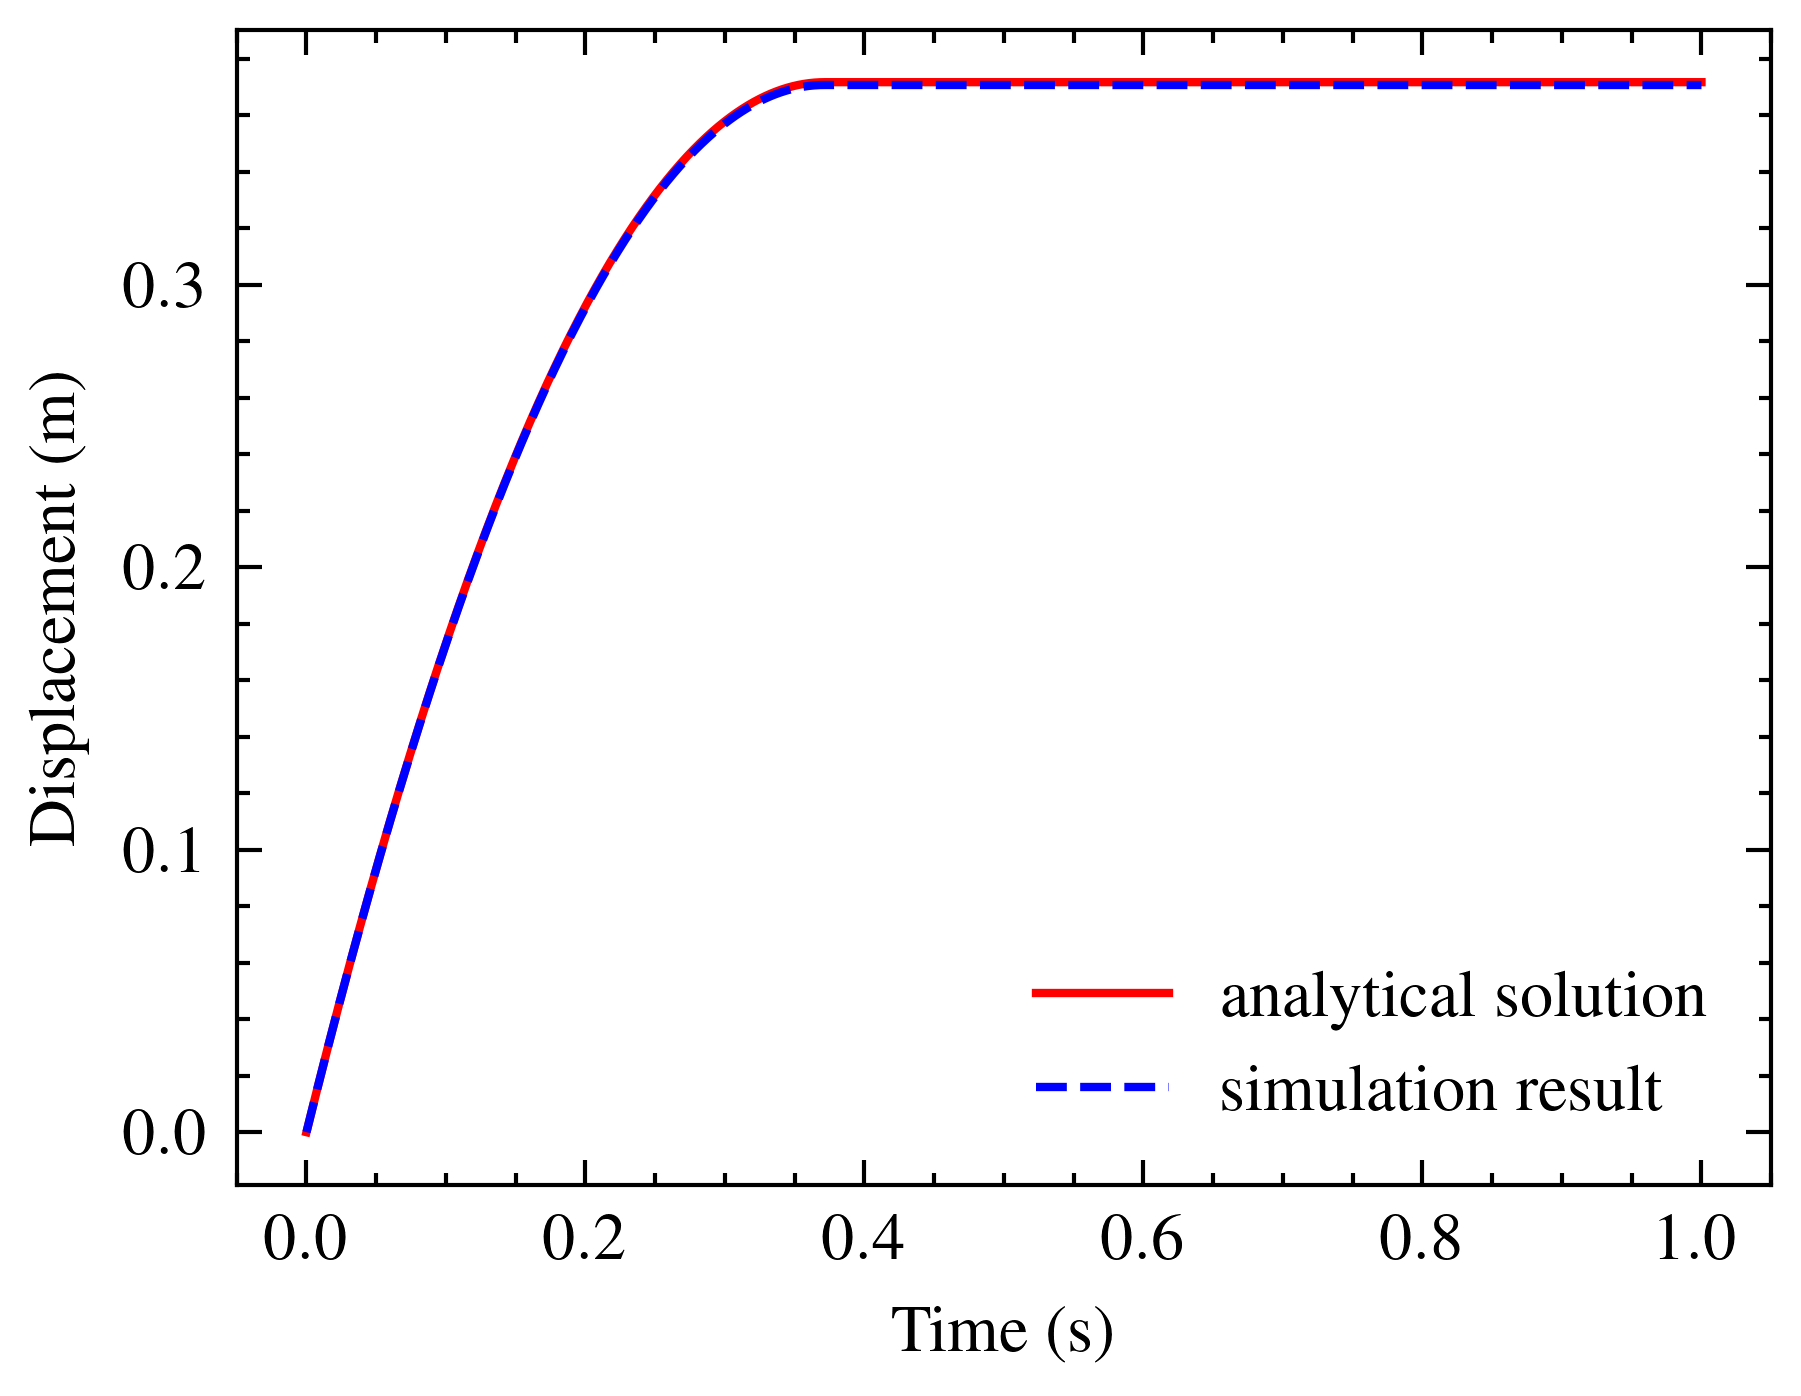

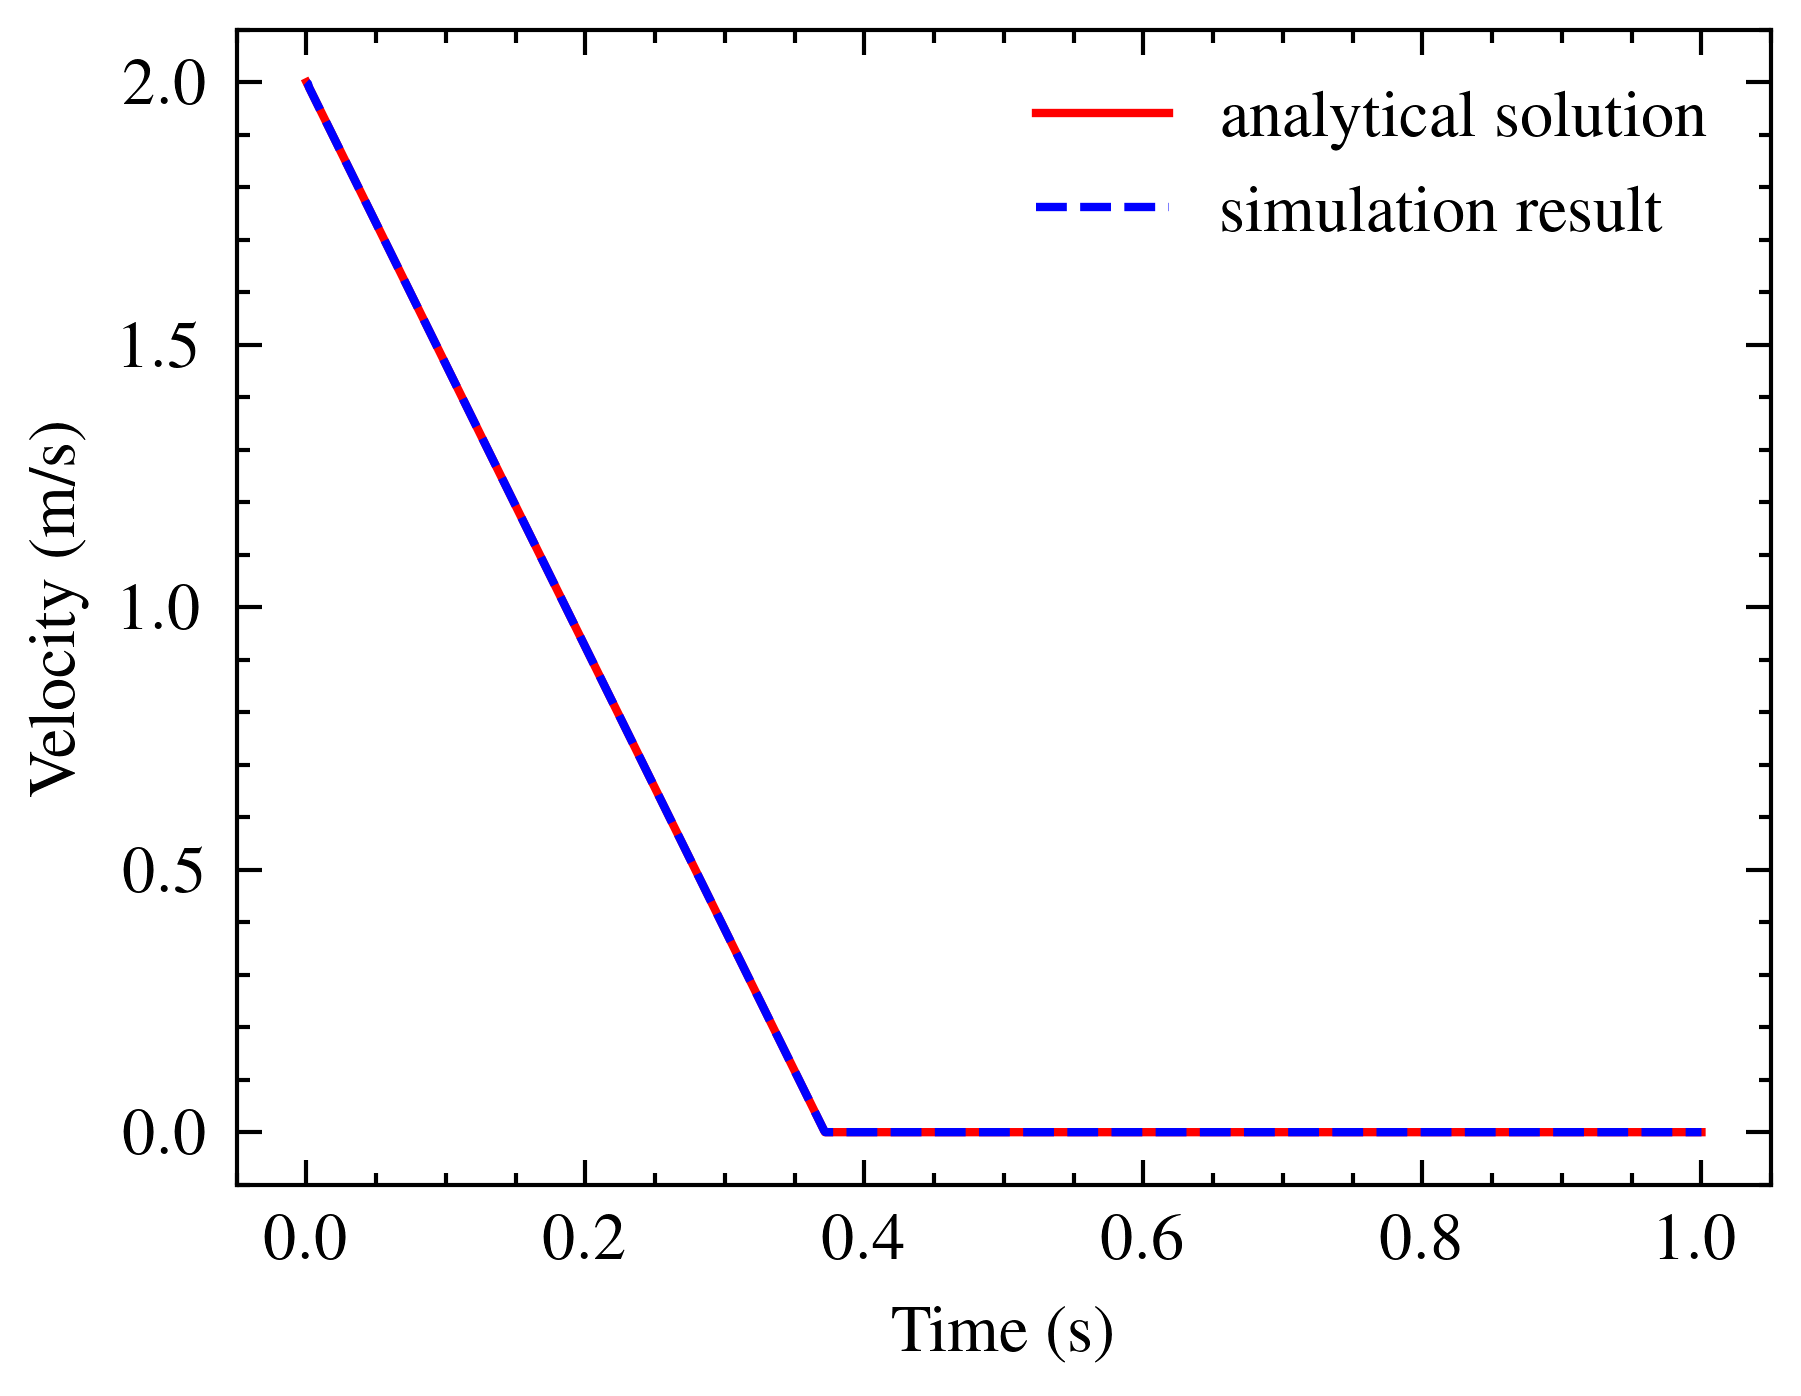

In [2]:
import numpy as np
plot_time = 1
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
dts = result["dts"]
x = []
y = []
yv = []

lowerBound = sire.binarySearch(timeIndices, 0)
upperBound = sire.binarySearch(timeIndices, 0 + plot_time)
print(timeIndices[lowerBound], timeIndices[lowerBound + 1])
for i in range(lowerBound, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  pm = sire.pq2tfmatrix(partpq[i][1])
  yOffset = pm[1, 3]
  zOffset = pm[2, 3] - cube_pe[2]
  y.append(math.sqrt(yOffset ** 2 + zOffset ** 2))  # z position from transformation matrix
  yv.append(math.sqrt(partvs[i][1][2] ** 2 + partvs[i][1][1]**2))  # z velocity

t = 2 / (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15)))
xt = 2 * t - 0.5 * (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * t ** 2
x2 = np.linspace(0, plot_time, 10000)
y2 = np.piecewise(x2, 
                 [x2 <= t, x2 > t], 
                 [lambda x: 2 * x - 0.5 * (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * x ** 2, lambda x: xt])
with plt.style.context(['science','ieee']):
  plt.plot(x2, y2, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, y, color='blue', linestyle="--", label="simulation result")
  plt.legend()
  plt.xlabel("Time (s)")
  plt.ylabel("Displacement (m)")
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data2.pdf", format="pdf")
  plt.show()

  x1 = np.linspace(0, plot_time, 10000)
  y1 = np.piecewise(x1, 
                   [x1 < t, x1 >= t], 
                   [lambda x: 2 - (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * x, lambda x: 0])
  plt.plot(x1, y1, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, yv, color='blue', linestyle="--", label="simulation result")
  plt.xlabel("Time (s)")
  plt.ylabel("Velocity (m/s)")
  plt.legend()
  plt.show()


  Sire Accuracy Metrics — Box Sliding on 15° Incline

                                  — Full Trajectory (0 — 1.0s) —
                                    Displacement        Velocity
  --------------------------------------------------------------
  RMSE:                                 0.000868        0.000096
  MAE:                                  0.000814        0.000028
  Max absolute error:                   0.001006        0.002865
  R² score:                             0.999908        1.000000

                                 — Stable Phase (t >= 0.3716s) —
  Analytical final displacement:        0.371627 m
  Sire mean displacement:               0.370626 m
  Sire displacement std:                0.000003 m
  Sire velocity std:                    0.000004 m/s
  Displacement abs diff:                0.001002 m
  Displacement rel diff:                  0.2695 %
  Displacement RMSE:                    0.001002 m
  Velocity RMSE:                        0.000039 m/s
[0.00e+00 1.

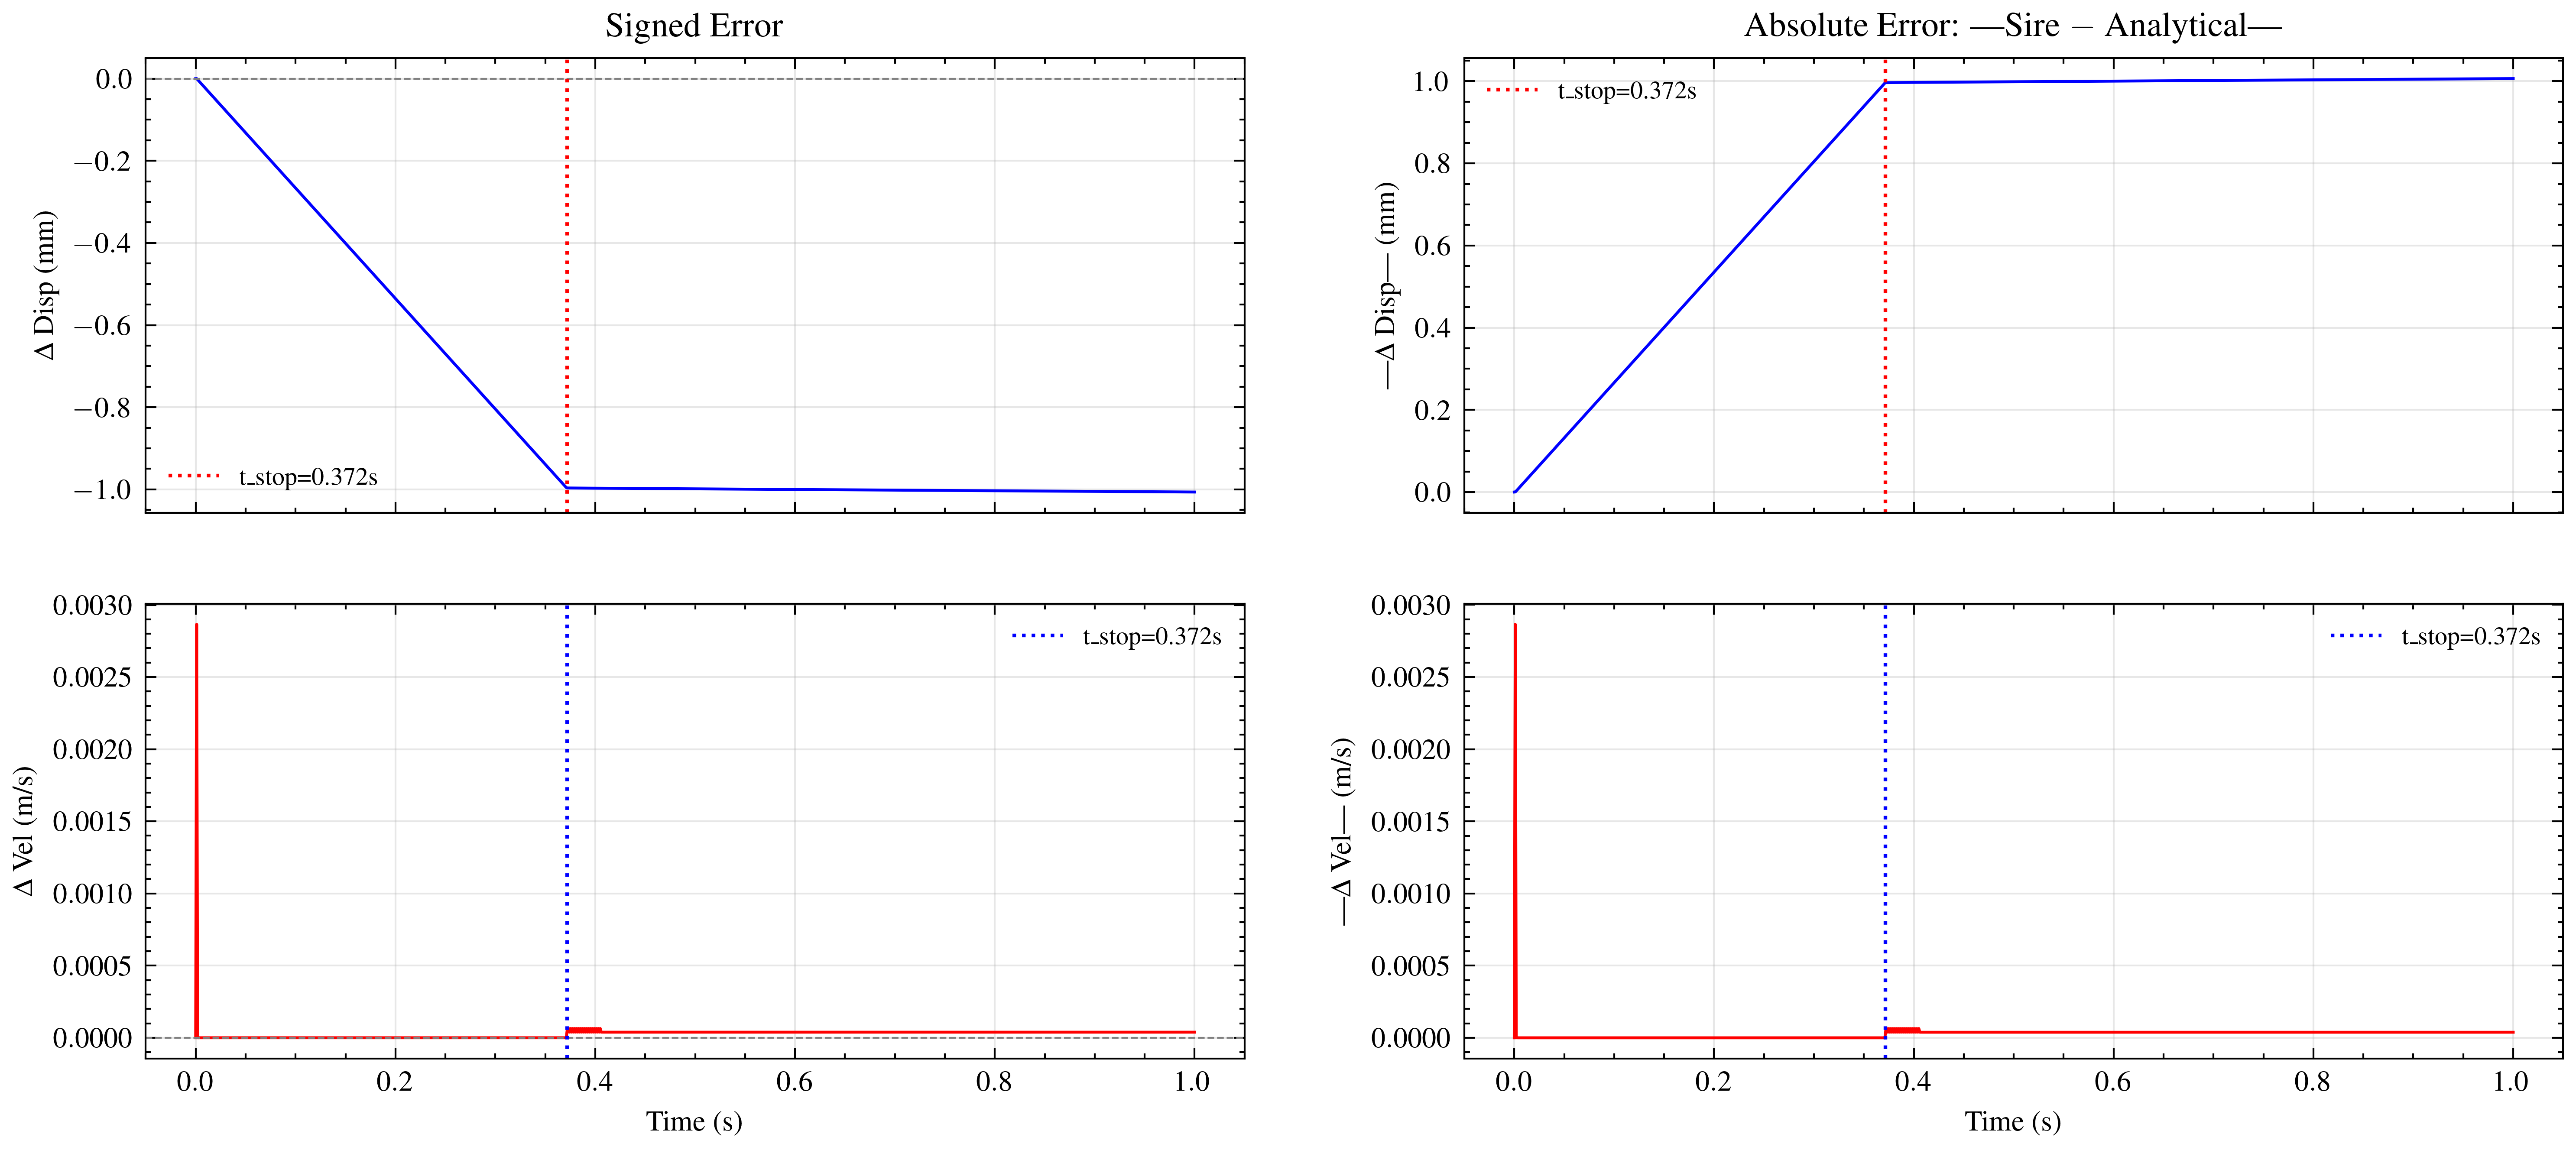

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ======================== Parameters & Analytical ========================
angle_deg = 15
angle_rad = math.radians(angle_deg)
g = 9.81
mu = 0.3
v0 = 2.0
a_decel = g * math.sin(angle_rad) + mu * g * math.cos(angle_rad)
t_stop = v0 / a_decel
x_stop = v0 * t_stop - 0.5 * a_decel * t_stop**2

# ======================== Analytical curves (fine grid) ========================
t_ana = np.linspace(0, 0.6, 10000)
disp_ana = np.piecewise(t_ana,
                        [t_ana <= t_stop, t_ana > t_stop],
                        [lambda t: v0*t - 0.5*a_decel*t**2,
                         lambda t: x_stop])
vel_ana = np.piecewise(t_ana,
                       [t_ana < t_stop, t_ana >= t_stop],
                       [lambda t: v0 - a_decel*t,
                        lambda t: 0])

# Interpolate analytical onto sire time points
x_arr = np.array(x)
y_arr = np.array(y)
yv_arr = np.array(yv)

disp_ana_at_sire = np.interp(x_arr, t_ana, disp_ana)
vel_ana_at_sire = np.interp(x_arr, t_ana, vel_ana)

# ======================== Full-Trajectory Errors ========================
disp_error = y_arr - disp_ana_at_sire
vel_error = yv_arr - vel_ana_at_sire

disp_rmse_full = np.sqrt(np.mean(disp_error**2))
vel_rmse_full = np.sqrt(np.mean(vel_error**2))
disp_mae_full = np.mean(np.abs(disp_error))
vel_mae_full = np.mean(np.abs(vel_error))
disp_max_err = np.max(np.abs(disp_error))
vel_max_err = np.max(np.abs(vel_error))

ss_res_d = np.sum(disp_error**2)
ss_tot_d = np.sum((y_arr - np.mean(y_arr))**2)
r2_disp = 1 - ss_res_d / ss_tot_d if ss_tot_d > 1e-15 else 1.0

ss_res_v = np.sum(vel_error**2)
ss_tot_v = np.sum((yv_arr - np.mean(yv_arr))**2)
r2_vel = 1 - ss_res_v / ss_tot_v if ss_tot_v > 1e-15 else 1.0

# ======================== Stable-Phase Errors ========================
stable_mask = x_arr >= t_stop
sire_stable_disp = y_arr[stable_mask]
sire_stable_vel = yv_arr[stable_mask]
stable_disp_mean = np.mean(sire_stable_disp)
stable_disp_std = np.std(sire_stable_disp)
stable_vel_std = np.std(sire_stable_vel)
stable_disp_abs_diff = abs(stable_disp_mean - x_stop)
stable_disp_rmse = np.sqrt(np.mean((sire_stable_disp - x_stop)**2))
stable_vel_rmse = np.sqrt(np.mean(sire_stable_vel**2))

# ======================== Print Results ========================
print(f"\n{'='*62}")
print(f"  Sire Accuracy Metrics — Box Sliding on {angle_deg}° Incline")
print(f"{'='*62}")

traj_label = f"— Full Trajectory (0 — {plot_time:.1f}s) —"
print(f"\n  {traj_label:>62}")
print(f"  {'':>30} {'Displacement':>15} {'Velocity':>15}")
print(f"  {'-'*62}")
print(f"  {'RMSE:':<30} {disp_rmse_full:>15.6f} {vel_rmse_full:>15.6f}")
print(f"  {'MAE:':<30} {disp_mae_full:>15.6f} {vel_mae_full:>15.6f}")
print(f"  {'Max absolute error:':<30} {disp_max_err:>15.6f} {vel_max_err:>15.6f}")
print(f"  {'R² score:':<30} {r2_disp:>15.6f} {r2_vel:>15.6f}")

stable_label = f"— Stable Phase (t >= {t_stop:.4f}s) —"
print(f"\n  {stable_label:>62}")
print(f"  {'Analytical final displacement:':<30} {x_stop:>15.6f} m")
print(f"  {'Sire mean displacement:':<30} {stable_disp_mean:>15.6f} m")
print(f"  {'Sire displacement std:':<30} {stable_disp_std:>15.6f} m")
print(f"  {'Sire velocity std:':<30} {stable_vel_std:>15.6f} m/s")
print(f"  {'Displacement abs diff:':<30} {stable_disp_abs_diff:>15.6f} m")
print(f"  {'Displacement rel diff:':<30} {stable_disp_abs_diff/x_stop*100:>15.4f} %")
print(f"  {'Displacement RMSE:':<30} {stable_disp_rmse:>15.6f} m")
print(f"  {'Velocity RMSE:':<30} {stable_vel_rmse:>15.6f} m/s")
print(f"{'='*62}")

# ======================== Plots ========================
with plt.style.context(['science', 'ieee']):
    # --- Error-over-time (2x2: signed + absolute) ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)

    axes[0, 0].plot(x_arr, disp_error * 1000, 'b-', linewidth=0.8)
    axes[0, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    axes[0, 0].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[0, 0].set_ylabel("$\\Delta$ Disp (mm)")
    axes[0, 0].set_title("Signed Error")
    axes[0, 0].legend(fontsize=7)
    axes[0, 0].grid(True, alpha=0.3)
    np.set_printoptions(threshold=np.inf)
    print(x_arr)
    print(disp_error)
    print(vel_error)

    axes[0, 1].plot(x_arr, np.abs(disp_error) * 1000, 'b-', linewidth=0.8)
    axes[0, 1].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[0, 1].set_ylabel("|$\\Delta$ Disp| (mm)")
    axes[0, 1].set_title("Absolute Error: |Sire $-$ Analytical|")
    axes[0, 1].legend(fontsize=7)
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(x_arr, vel_error, 'r-', linewidth=0.8)
    axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    axes[1, 0].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[1, 0].set_xlabel("Time (s)")
    axes[1, 0].set_ylabel("$\\Delta$ Vel (m/s)")
    axes[1, 0].legend(fontsize=7)
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(x_arr, np.abs(vel_error), 'r-', linewidth=0.8)
    axes[1, 1].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[1, 1].set_xlabel("Time (s)")
    axes[1, 1].set_ylabel("|$\\Delta$ Vel| (m/s)")
    axes[1, 1].legend(fontsize=7)
    axes[1, 1].grid(True, alpha=0.3)

    plt.show()

# Analytical Tangential Solver

In [ ]:
import matplotlib.pyplot as plt
import scienceplots
import math
import numpy as np

def calculate_inclined_positions(angle_deg=10):
    """
    计算小方块在10度斜面上的位置
    
    参数:
    angle_deg: 斜面角度(度)
    """
    # 角度转换为弧度
    angle_rad = math.radians(angle_deg)
    
    # 当前参数
    ground_height = 0.5  # 地面几何中心z坐标
    ground_thickness = 1  # 地面厚度
    cube_size = 1         # 小方块尺寸
    
    # 计算斜面位置
    # 斜面绕x轴旋转10度，保持地面顶部与原点相切
    ground_pe = [0, 0, ground_height, 0, -angle_rad, 0]  # [x,y,z,rx,ry,rz]
    
    # 计算小方块位置
    # 小方块应该放在斜面上，底部四个小球与斜面接触
    cube_height = ground_height + (cube_size + ground_thickness) * 0.5 / math.cos(angle_rad)
    # cube_z_offset = sphere_radius + (cube_size/2 - 0.4)  # 考虑小球半径和几何偏移
    # cube_height = cube_z_offset + (cube_size/2) * math.sin(angle_rad)
    
    # 小方块的位置和姿态
    cube_pe = [0, 0, cube_height, 0, -angle_rad, 0]
    
    return ground_pe, cube_pe

  # import sys
  # sys.path.append("D:/code/sire/install/python/debug")
import sire
sim = sire.Simulator()
model = sim.model()
model.addSolvers()
simulator = sim.simulationLoop()
simulator.simDuration = 2
simulator.deltaT = 0.001
simulator.ctrlT = 10
simulator.setEventHandlerMap({0:9, 1:10, 2:11})
physicsEngine = sim.physicsEngine()
contactSolver = physicsEngine.addAnalyticalTangentForceSolver()
physicsEngine.collisionDetectionFlag = True
physicsEngine.contactSolverFlag = True
contactSolver.setDefaultProp("{k:1.4e8,d:10000,cr:0.2}")
# contactSolver.setDefaultProp("{k:2e7,d:10000,cr:0.2}")
# contactSolver.addMaterialPair("m1", "m1", "{k:2e8,d:10000,cr:0,cof:0.3,threshold_velocity:2e-6}")
contactSolver.addMaterialPair("m1", "m2", "{k:2e8,d:150000,cr:0.2,cof:0.3,threshold_velocity:1e-5}")
model.setGravity([0, 0, -9.81, 0, 0, 0])
model.ground().addMarker("joint_0_k")
model.ground().addMarker("ground_marker")
ground_pe, cube_pe = calculate_inclined_positions(15)
# cube_pe[2] = 2
ground_pm = sire.pe3132tfmatrix(ground_pe).tolist()
model.ground().addBoxGeometry(0, 100, 100, 1, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
model.ground().addBoxGeometry(0, 5, 5, 1, ground_pm)

physicsEngine.addBoxGeometry(100, 100, 1, 0, False, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
physicsEngine.addBoxGeometry(5, 5, 1, 0, False, ground_pm)
# sliderPrt = model.addPartByPe(ground_pe, "313", [10, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
# model.link(1).addMarker("slider_center")
boxPrt = model.addPartByPe(cube_pe, "313", [1, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
model.link(1).addMarker("box_center")
model.init()
boxPrt.addBoxGeometry(boxPrt.id, 1.0, 1.0, 1.0, prt_pm=[1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1])
boxPrt.cptGeometryInertial2Part(1)
boxPrt.vs = sire.vp2vs(cube_pe[:3], [0, -2 * math.cos(math.radians(15)), 2 * math.sin(math.radians(15))])

physicsEngine.addBoxGeometry(1, 1, 1, boxPrt.id, True)
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
# print(sire.toXmlString(sim))
sim.init()
for i in range(4):
  physicsEngine.collisionFilter().enableCollisionPair(1, i + 3)

physicsEngine.collisionFilter().saveMatConfig()
print(sire.toXmlString(sim))

count = 0
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  sim_time = simulator.simTime()
  # if abs(sim_time - 0.37) < 1e-8 and count == 0:
  #   print(boxPrt.getAs())
  #   count += 1
  simulator.step(1, False)

simulator.recordsContactCptInfo()
displayInitJson = model.displayInitJson()
result = simulator.recordsToJson()

# pltResult = result
# timeIndices = pltResult['timeIndex']
# pp = pltResult["penetrationPairs"]  # contactInfo is renamed to penetrationPairs in the latest code
# partpq = pltResult["partPq"]
# partvs = pltResult["partVs"]
# partas = pltResult["partAs"]
# gf = pltResult["generalForces"]
# dts = pltResult["dts"]
# x = []
# y = []
# yv = []
# # print(result[i][2])

# lowerBound = sire.binarySearch(timeIndices, 0.16)
# upperBound = sire.binarySearch(timeIndices, 0.198)
# print(lowerBound, upperBound)
# # with open('hfield_data.txt', 'w') as f:          # 'w' 覆盖写，'a' 追加写
# # with open('box_data.txt', 'w') as f:          # 'w' 覆盖写，'a' 追加写
# for j in range(lowerBound, upperBound):
#     # print(j, f"{timeIndices[j]:.4f}", f"{dts[j]:.4f}", f"{partpq[j][1][2]:.6f}", f"{partvs[j][1][2]:.6f}", f"{partas[j][1][2]:.6f}", pp[j], gf[j], file=f)
#   print(j, f"{timeIndices[j]:.4f}", f"{dts[j]:.4f}", f"{partpq[j][1][2]:.6f}", f"{partvs[j][1][2]:.6f}", f"{partas[j][1][2]:.6f}", pp[j], gf[j])

print("Simulation finished, records loaded")
import meshcat
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/web_interface/public"
sire.robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
sire.animateRobotByRecords(model.numLinks(), result, 1000, vis)
# cs.clear()
vis.jupyter_cell()

<Simulator>
    <Model __prop_name__="model" name="object" time="0">
        <Environment __prop_name__="environment" gravity="{0,0,-9.81,0,0,0}"/>
        <VariablePoolElement __prop_name__="variable_pool"/>
        <PartPoolElement __prop_name__="part_pool">
            <Part name="ground" active="true" pe="{0,0,0,-0,0,-0}" vel="{0,0,0,0,0,0}" acc="{0,0,0,0,0,0}" inertia="{1,0,0,0,1,1,1,0,0,0}">
                <MarkerPoolElement __prop_name__="marker_pool">
                    <Marker name="joint_0_k" active="true" pe="{0,0,0,-0,0,-0}"/>
                    <Marker name="ground_marker" active="true" pe="{0,0,0,-0,0,-0}"/>
                </MarkerPoolElement>
                <GeometryPoolElement __prop_name__="geometry_pool">
                    <BoxGeometry id="0" pm="{1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1}" part_id="0" is_dynamic="true" side="{100,100,1}"/>
                    <BoxGeometry id="1" pm="{1,-0,0,0,0,0.965925826289068,0.258819045102521,0,-0,-0.258819045102521,0.96592582628

0.0 0.001


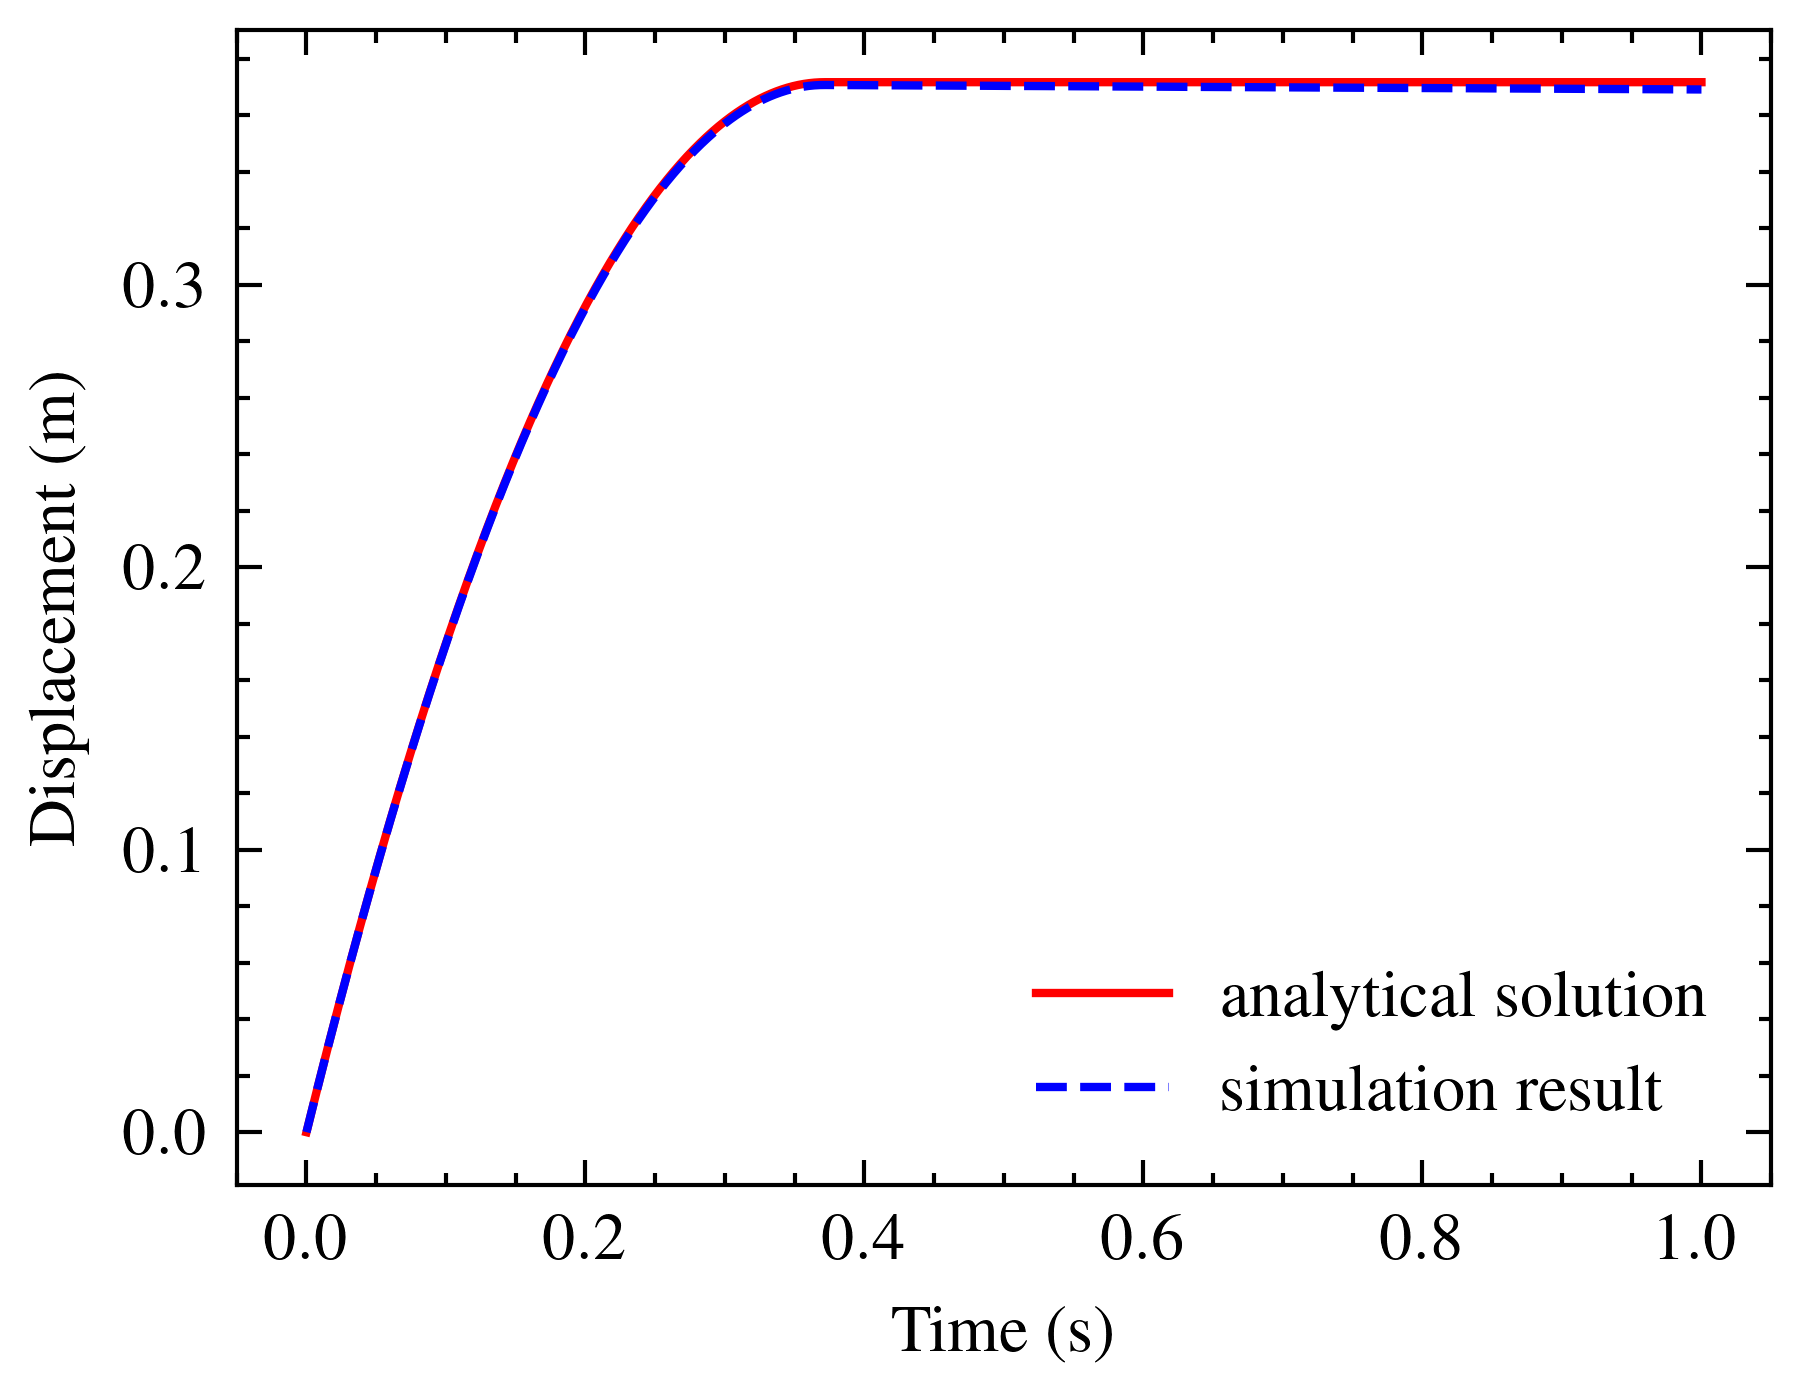

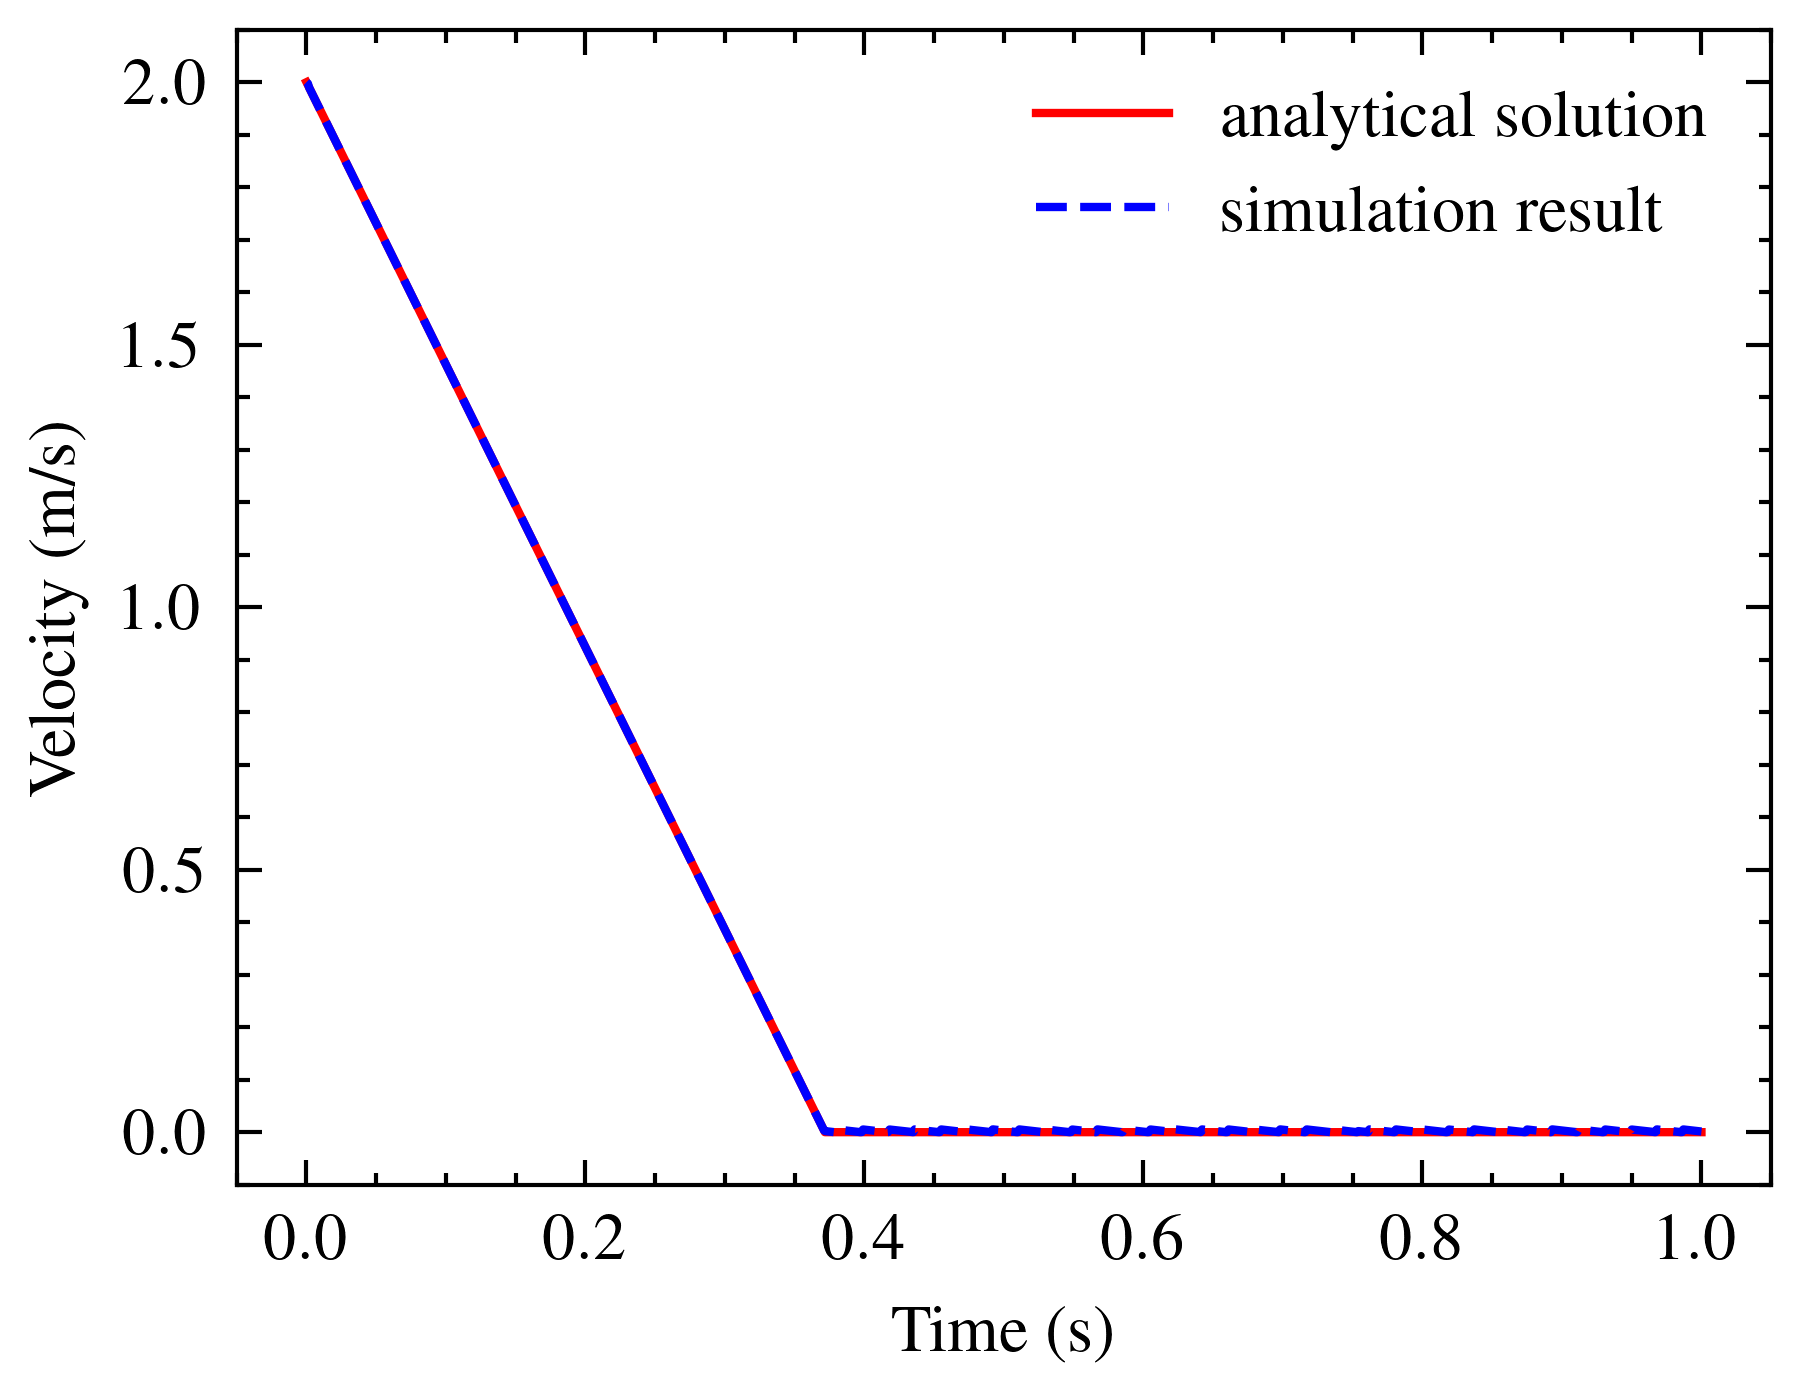

In [2]:
import numpy as np
plot_time = 1
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
dts = result["dts"]
x = []
y = []
yv = []

lowerBound = sire.binarySearch(timeIndices, 0)
upperBound = sire.binarySearch(timeIndices, 0 + plot_time)
print(timeIndices[lowerBound], timeIndices[lowerBound + 1])
for i in range(lowerBound, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  pm = sire.pq2tfmatrix(partpq[i][1])
  yOffset = pm[1, 3]
  zOffset = pm[2, 3] - cube_pe[2]
  y.append(math.sqrt(yOffset ** 2 + zOffset ** 2))  # z position from transformation matrix
  yv.append(math.sqrt(partvs[i][1][2] ** 2 + partvs[i][1][1]**2))  # z velocity

t = 2 / (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15)))
xt = 2 * t - 0.5 * (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * t ** 2
x2 = np.linspace(0, plot_time, 10000)
y2 = np.piecewise(x2, 
                 [x2 <= t, x2 > t], 
                 [lambda x: 2 * x - 0.5 * (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * x ** 2, lambda x: xt])
with plt.style.context(['science','ieee']):
  plt.plot(x2, y2, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, y, color='blue', linestyle="--", label="simulation result")
  plt.legend()
  plt.xlabel("Time (s)")
  plt.ylabel("Displacement (m)")
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data2.pdf", format="pdf")
  plt.show()

  x1 = np.linspace(0, plot_time, 10000)
  y1 = np.piecewise(x1, 
                   [x1 < t, x1 >= t], 
                   [lambda x: 2 - (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * x, lambda x: 0])
  plt.plot(x1, y1, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, yv, color='blue', linestyle="--", label="simulation result")
  plt.xlabel("Time (s)")
  plt.ylabel("Velocity (m/s)")
  plt.legend()
  plt.show()


  Sire Accuracy Metrics — Box Sliding on 15° Incline

                                  — Full Trajectory (0 — 1.0s) —
                                    Displacement        Velocity
  --------------------------------------------------------------
  RMSE:                                 0.001504        0.002382
  MAE:                                  0.001308        0.001594
  Max absolute error:                   0.002580        0.005371
  R² score:                             0.999721        0.999984

                                 — Stable Phase (t >= 0.3716s) —
  Analytical final displacement:        0.371627 m
  Sire mean displacement:               0.369840 m
  Sire displacement std:                0.000457 m
  Sire velocity std:                    0.001613 m/s
  Displacement abs diff:                0.001787 m
  Displacement rel diff:                  0.4810 %
  Displacement RMSE:                    0.001845 m
  Velocity RMSE:                        0.003003 m/s
[0.00e+00 1.

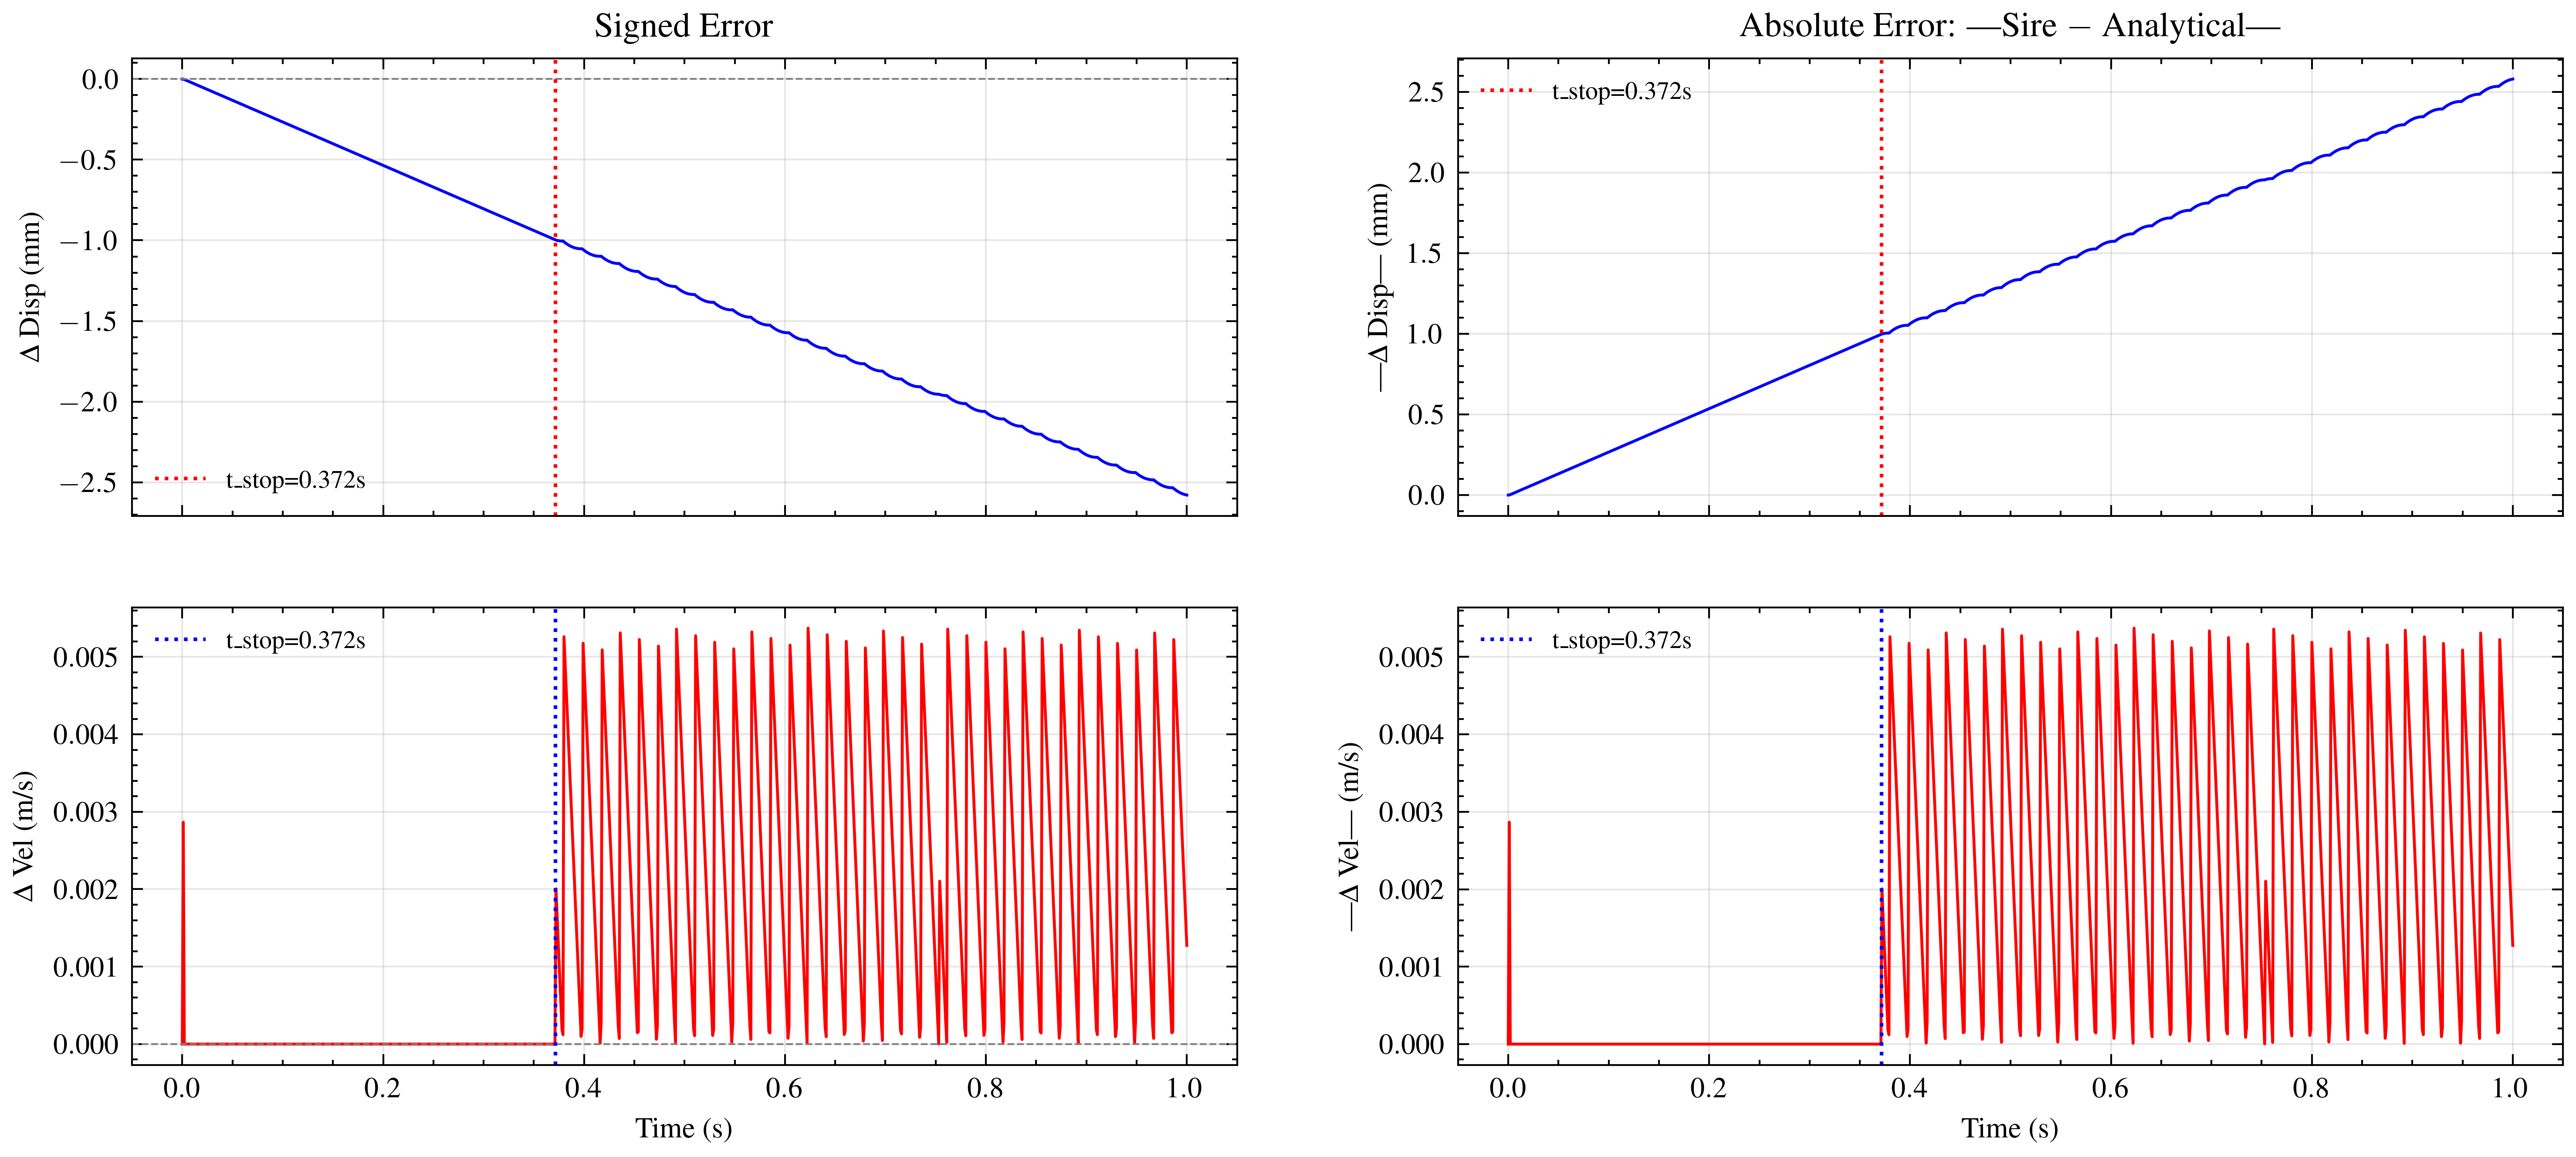

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ======================== Parameters & Analytical ========================
angle_deg = 15
angle_rad = math.radians(angle_deg)
g = 9.81
mu = 0.3
v0 = 2.0
a_decel = g * math.sin(angle_rad) + mu * g * math.cos(angle_rad)
t_stop = v0 / a_decel
x_stop = v0 * t_stop - 0.5 * a_decel * t_stop**2

# ======================== Analytical curves (fine grid) ========================
t_ana = np.linspace(0, 0.6, 10000)
disp_ana = np.piecewise(t_ana,
                        [t_ana <= t_stop, t_ana > t_stop],
                        [lambda t: v0*t - 0.5*a_decel*t**2,
                         lambda t: x_stop])
vel_ana = np.piecewise(t_ana,
                       [t_ana < t_stop, t_ana >= t_stop],
                       [lambda t: v0 - a_decel*t,
                        lambda t: 0])

# Interpolate analytical onto sire time points
x_arr = np.array(x)
y_arr = np.array(y)
yv_arr = np.array(yv)

disp_ana_at_sire = np.interp(x_arr, t_ana, disp_ana)
vel_ana_at_sire = np.interp(x_arr, t_ana, vel_ana)

# ======================== Full-Trajectory Errors ========================
disp_error = y_arr - disp_ana_at_sire
vel_error = yv_arr - vel_ana_at_sire

disp_rmse_full = np.sqrt(np.mean(disp_error**2))
vel_rmse_full = np.sqrt(np.mean(vel_error**2))
disp_mae_full = np.mean(np.abs(disp_error))
vel_mae_full = np.mean(np.abs(vel_error))
disp_max_err = np.max(np.abs(disp_error))
vel_max_err = np.max(np.abs(vel_error))

ss_res_d = np.sum(disp_error**2)
ss_tot_d = np.sum((y_arr - np.mean(y_arr))**2)
r2_disp = 1 - ss_res_d / ss_tot_d if ss_tot_d > 1e-15 else 1.0

ss_res_v = np.sum(vel_error**2)
ss_tot_v = np.sum((yv_arr - np.mean(yv_arr))**2)
r2_vel = 1 - ss_res_v / ss_tot_v if ss_tot_v > 1e-15 else 1.0

# ======================== Stable-Phase Errors ========================
stable_mask = x_arr >= t_stop
sire_stable_disp = y_arr[stable_mask]
sire_stable_vel = yv_arr[stable_mask]
stable_disp_mean = np.mean(sire_stable_disp)
stable_disp_std = np.std(sire_stable_disp)
stable_vel_std = np.std(sire_stable_vel)
stable_disp_abs_diff = abs(stable_disp_mean - x_stop)
stable_disp_rmse = np.sqrt(np.mean((sire_stable_disp - x_stop)**2))
stable_vel_rmse = np.sqrt(np.mean(sire_stable_vel**2))

# ======================== Print Results ========================
print(f"\n{'='*62}")
print(f"  Sire Accuracy Metrics — Box Sliding on {angle_deg}° Incline")
print(f"{'='*62}")

traj_label = f"— Full Trajectory (0 — {plot_time:.1f}s) —"
print(f"\n  {traj_label:>62}")
print(f"  {'':>30} {'Displacement':>15} {'Velocity':>15}")
print(f"  {'-'*62}")
print(f"  {'RMSE:':<30} {disp_rmse_full:>15.6f} {vel_rmse_full:>15.6f}")
print(f"  {'MAE:':<30} {disp_mae_full:>15.6f} {vel_mae_full:>15.6f}")
print(f"  {'Max absolute error:':<30} {disp_max_err:>15.6f} {vel_max_err:>15.6f}")
print(f"  {'R² score:':<30} {r2_disp:>15.6f} {r2_vel:>15.6f}")

stable_label = f"— Stable Phase (t >= {t_stop:.4f}s) —"
print(f"\n  {stable_label:>62}")
print(f"  {'Analytical final displacement:':<30} {x_stop:>15.6f} m")
print(f"  {'Sire mean displacement:':<30} {stable_disp_mean:>15.6f} m")
print(f"  {'Sire displacement std:':<30} {stable_disp_std:>15.6f} m")
print(f"  {'Sire velocity std:':<30} {stable_vel_std:>15.6f} m/s")
print(f"  {'Displacement abs diff:':<30} {stable_disp_abs_diff:>15.6f} m")
print(f"  {'Displacement rel diff:':<30} {stable_disp_abs_diff/x_stop*100:>15.4f} %")
print(f"  {'Displacement RMSE:':<30} {stable_disp_rmse:>15.6f} m")
print(f"  {'Velocity RMSE:':<30} {stable_vel_rmse:>15.6f} m/s")
print(f"{'='*62}")

# ======================== Plots ========================
with plt.style.context(['science', 'ieee']):
    # --- Error-over-time (2x2: signed + absolute) ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)

    axes[0, 0].plot(x_arr, disp_error * 1000, 'b-', linewidth=0.8)
    axes[0, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    axes[0, 0].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[0, 0].set_ylabel("$\\Delta$ Disp (mm)")
    axes[0, 0].set_title("Signed Error")
    axes[0, 0].legend(fontsize=7)
    axes[0, 0].grid(True, alpha=0.3)
    np.set_printoptions(threshold=np.inf)
    print(x_arr)
    print(disp_error)
    print(vel_error)

    axes[0, 1].plot(x_arr, np.abs(disp_error) * 1000, 'b-', linewidth=0.8)
    axes[0, 1].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[0, 1].set_ylabel("|$\\Delta$ Disp| (mm)")
    axes[0, 1].set_title("Absolute Error: |Sire $-$ Analytical|")
    axes[0, 1].legend(fontsize=7)
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(x_arr, vel_error, 'r-', linewidth=0.8)
    axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    axes[1, 0].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[1, 0].set_xlabel("Time (s)")
    axes[1, 0].set_ylabel("$\\Delta$ Vel (m/s)")
    axes[1, 0].legend(fontsize=7)
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(x_arr, np.abs(vel_error), 'r-', linewidth=0.8)
    axes[1, 1].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[1, 1].set_xlabel("Time (s)")
    axes[1, 1].set_ylabel("|$\\Delta$ Vel| (m/s)")
    axes[1, 1].legend(fontsize=7)
    axes[1, 1].grid(True, alpha=0.3)

    plt.show()

# Analytical implicit contact solver

In [1]:
import matplotlib.pyplot as plt
import scienceplots
import math
import numpy as np

def calculate_inclined_positions(angle_deg=10):
    """
    计算小方块在10度斜面上的位置
    
    参数:
    angle_deg: 斜面角度(度)
    """
    # 角度转换为弧度
    angle_rad = math.radians(angle_deg)
    
    # 当前参数
    ground_height = 0.5  # 地面几何中心z坐标
    ground_thickness = 1  # 地面厚度
    cube_size = 1         # 小方块尺寸
    
    # 计算斜面位置
    # 斜面绕x轴旋转10度，保持地面顶部与原点相切
    ground_pe = [0, 0, ground_height, 0, -angle_rad, 0]  # [x,y,z,rx,ry,rz]
    
    # 计算小方块位置
    # 小方块应该放在斜面上，底部四个小球与斜面接触
    cube_height = ground_height + (cube_size + ground_thickness) * 0.5 / math.cos(angle_rad)
    # cube_z_offset = sphere_radius + (cube_size/2 - 0.4)  # 考虑小球半径和几何偏移
    # cube_height = cube_z_offset + (cube_size/2) * math.sin(angle_rad)
    
    # 小方块的位置和姿态
    cube_pe = [0, 0, cube_height, 0, -angle_rad, 0]
    
    return ground_pe, cube_pe

  # import sys
  # sys.path.append("D:/code/sire/install/python/debug")
import sire
sim = sire.Simulator()
model = sim.model()
model.addSolvers()
simulator = sim.simulationLoop()
simulator.simDuration = 2
simulator.deltaT = 0.001
simulator.ctrlT = 10
simulator.setEventHandlerMap({0:9, 1:10, 2:11})
physicsEngine = sim.physicsEngine()
contactSolver = physicsEngine.addAnalyticalImplicitFrictionSolver()
physicsEngine.collisionDetectionFlag = True
physicsEngine.contactSolverFlag = True
contactSolver.setDefaultProp("{k:1.4e8,d:10000,cr:0.2}")
# contactSolver.setDefaultProp("{k:2e7,d:10000,cr:0.2}")
# contactSolver.addMaterialPair("m1", "m1", "{k:2e8,d:10000,cr:0,cof:0.3,threshold_velocity:2e-6}")
contactSolver.addMaterialPair("m1", "m2", "{k:2e8,d:150000,cr:0.2,cof:0.3,threshold_velocity:1e-5}")
model.setGravity([0, 0, -9.81, 0, 0, 0])
model.ground().addMarker("joint_0_k")
model.ground().addMarker("ground_marker")
ground_pe, cube_pe = calculate_inclined_positions(15)
# cube_pe[2] = 2
ground_pm = sire.pe3132tfmatrix(ground_pe).tolist()
model.ground().addBoxGeometry(0, 100, 100, 1, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
model.ground().addBoxGeometry(0, 5, 5, 1, ground_pm)

physicsEngine.addBoxGeometry(100, 100, 1, 0, False, [1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1])
physicsEngine.addBoxGeometry(5, 5, 1, 0, False, ground_pm)
# sliderPrt = model.addPartByPe(ground_pe, "313", [10, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
# model.link(1).addMarker("slider_center")
boxPrt = model.addPartByPe(cube_pe, "313", [1, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0, 0])
model.link(1).addMarker("box_center")
model.init()
boxPrt.addBoxGeometry(boxPrt.id, 1.0, 1.0, 1.0, prt_pm=[1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1])
boxPrt.cptGeometryInertial2Part(1)
boxPrt.vs = sire.vp2vs(cube_pe[:3], [0, -2 * math.cos(math.radians(15)), 2 * math.sin(math.radians(15))])

physicsEngine.addBoxGeometry(1, 1, 1, boxPrt.id, True)
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,0.5,0,0,1,-0.4,0,0,0,1], material="m2")
physicsEngine.addSphereGeometry(0.1, boxPrt.id, True, [1,0,0,-0.5,0,1,0,-0.5,0,0,1,-0.4,0,0,0,1], material="m2")
# print(sire.toXmlString(sim))
sim.init()
for i in range(4):
  physicsEngine.collisionFilter().enableCollisionPair(1, i + 3)

physicsEngine.collisionFilter().saveMatConfig()
print(sire.toXmlString(sim))

count = 0
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  sim_time = simulator.simTime()
  # if abs(sim_time - 0.37) < 1e-8 and count == 0:
  #   print(boxPrt.getAs())
  #   count += 1
  simulator.step(1, False)

simulator.recordsContactCptInfo()
displayInitJson = model.displayInitJson()
result = simulator.recordsToJson()

# pltResult = result
# timeIndices = pltResult['timeIndex']
# pp = pltResult["penetrationPairs"]  # contactInfo is renamed to penetrationPairs in the latest code
# partpq = pltResult["partPq"]
# partvs = pltResult["partVs"]
# partas = pltResult["partAs"]
# gf = pltResult["generalForces"]
# dts = pltResult["dts"]
# x = []
# y = []
# yv = []
# # print(result[i][2])

# lowerBound = sire.binarySearch(timeIndices, 0.16)
# upperBound = sire.binarySearch(timeIndices, 0.198)
# print(lowerBound, upperBound)
# # with open('hfield_data.txt', 'w') as f:          # 'w' 覆盖写，'a' 追加写
# # with open('box_data.txt', 'w') as f:          # 'w' 覆盖写，'a' 追加写
# for j in range(lowerBound, upperBound):
#     # print(j, f"{timeIndices[j]:.4f}", f"{dts[j]:.4f}", f"{partpq[j][1][2]:.6f}", f"{partvs[j][1][2]:.6f}", f"{partas[j][1][2]:.6f}", pp[j], gf[j], file=f)
#   print(j, f"{timeIndices[j]:.4f}", f"{dts[j]:.4f}", f"{partpq[j][1][2]:.6f}", f"{partvs[j][1][2]:.6f}", f"{partas[j][1][2]:.6f}", pp[j], gf[j])

print("Simulation finished, records loaded")
import meshcat
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/web_interface/public"
sire.robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
sire.animateRobotByRecords(model.numLinks(), result, 1000, vis)
# cs.clear()
vis.jupyter_cell()

<Simulator>
    <Model __prop_name__="model" name="object" time="0">
        <Environment __prop_name__="environment" gravity="{0,0,-9.81,0,0,0}"/>
        <VariablePoolElement __prop_name__="variable_pool"/>
        <PartPoolElement __prop_name__="part_pool">
            <Part name="ground" active="true" pe="{0,0,0,-0,0,-0}" vel="{0,0,0,0,0,0}" acc="{0,0,0,0,0,0}" inertia="{1,0,0,0,1,1,1,0,0,0}">
                <MarkerPoolElement __prop_name__="marker_pool">
                    <Marker name="joint_0_k" active="true" pe="{0,0,0,-0,0,-0}"/>
                    <Marker name="ground_marker" active="true" pe="{0,0,0,-0,0,-0}"/>
                </MarkerPoolElement>
                <GeometryPoolElement __prop_name__="geometry_pool">
                    <BoxGeometry id="0" pm="{1,0,0,0,0,1,0,0,0,0,1,-0.5,0,0,0,1}" part_id="0" is_dynamic="true" side="{100,100,1}"/>
                    <BoxGeometry id="1" pm="{1,-0,0,0,0,0.965925826289068,0.258819045102521,0,-0,-0.258819045102521,0.96592582628

0.0 0.001


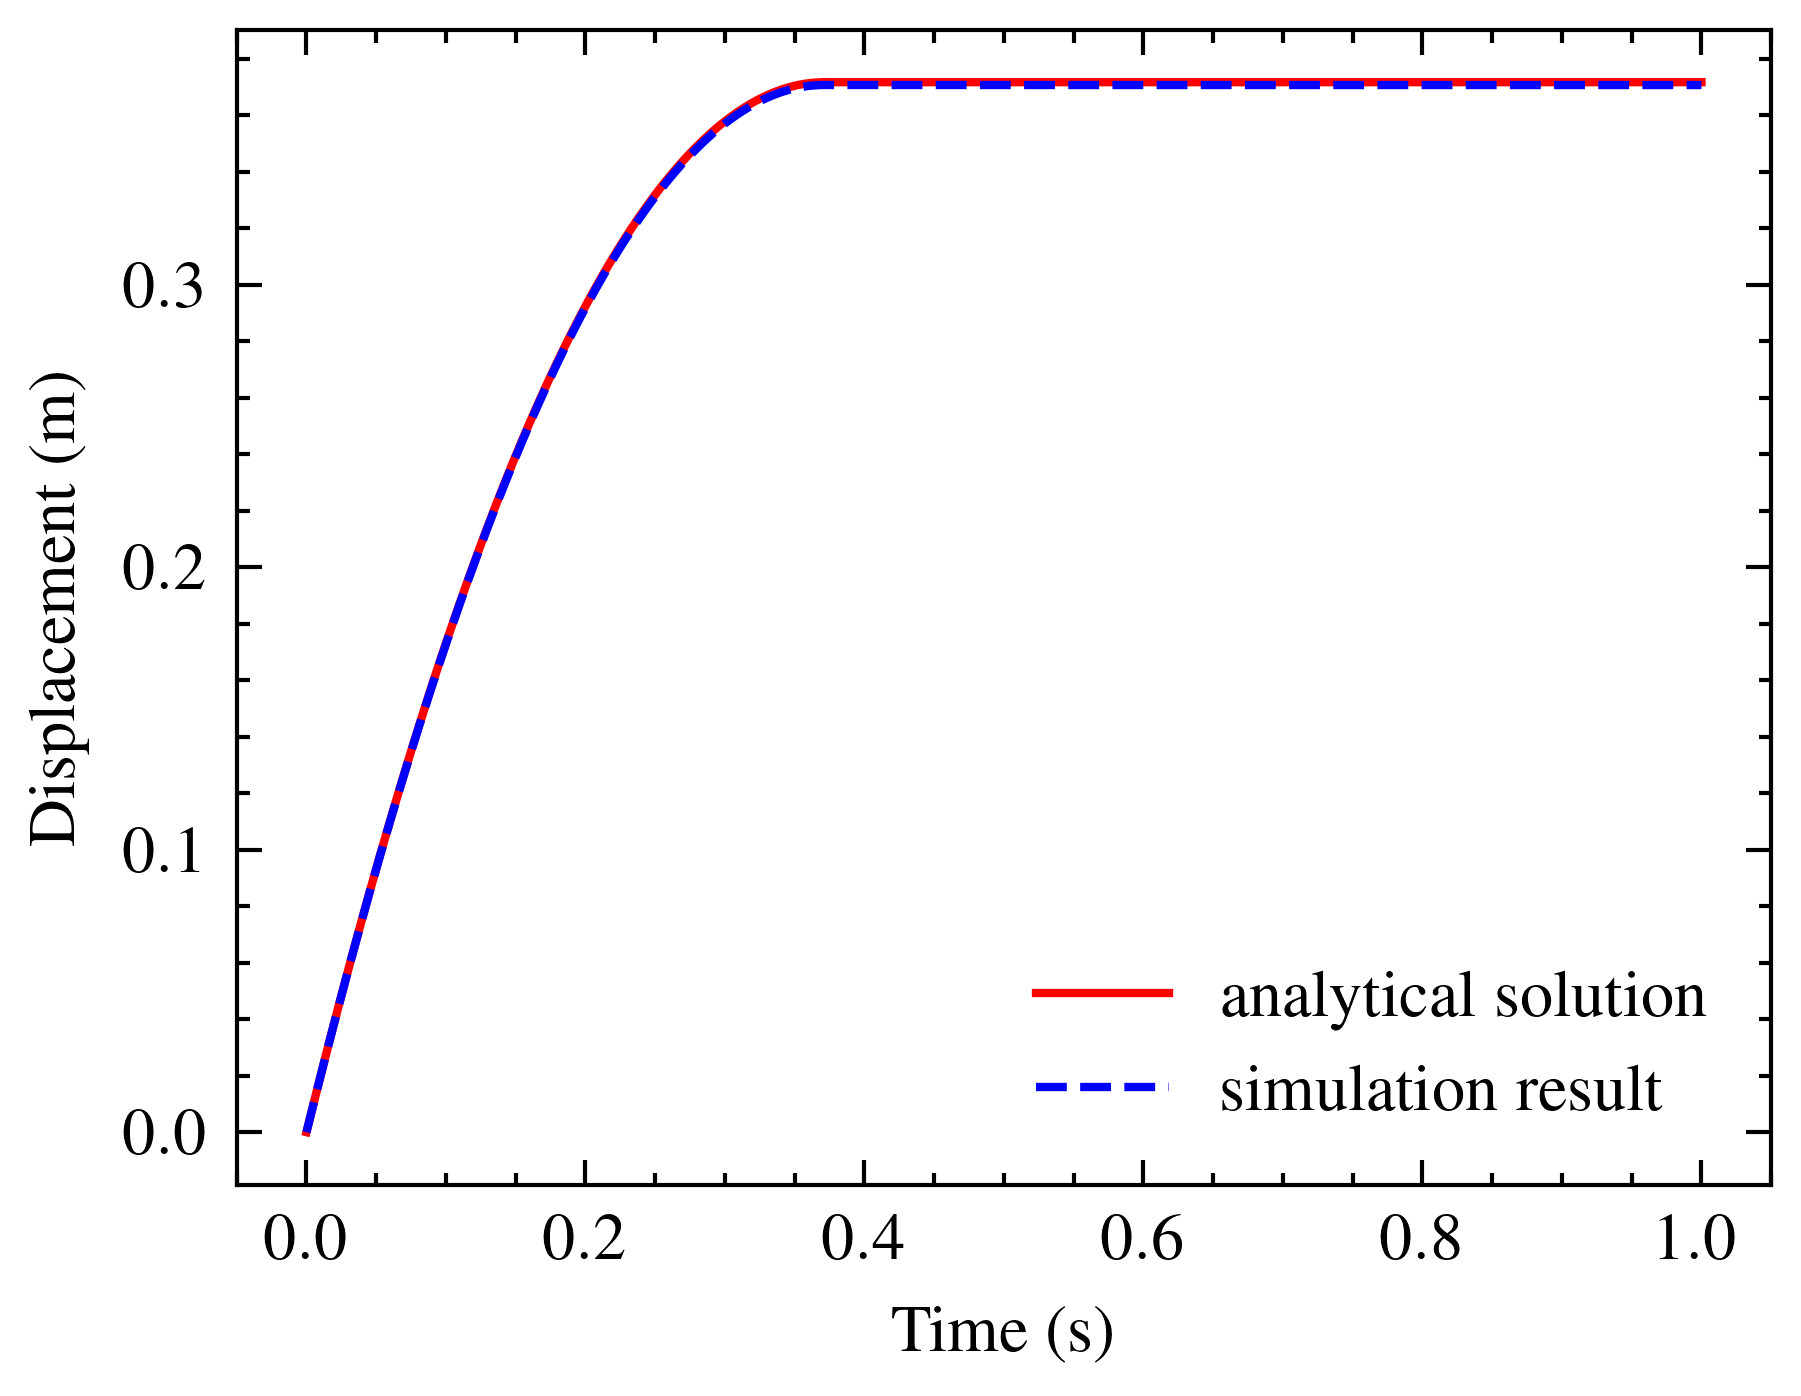

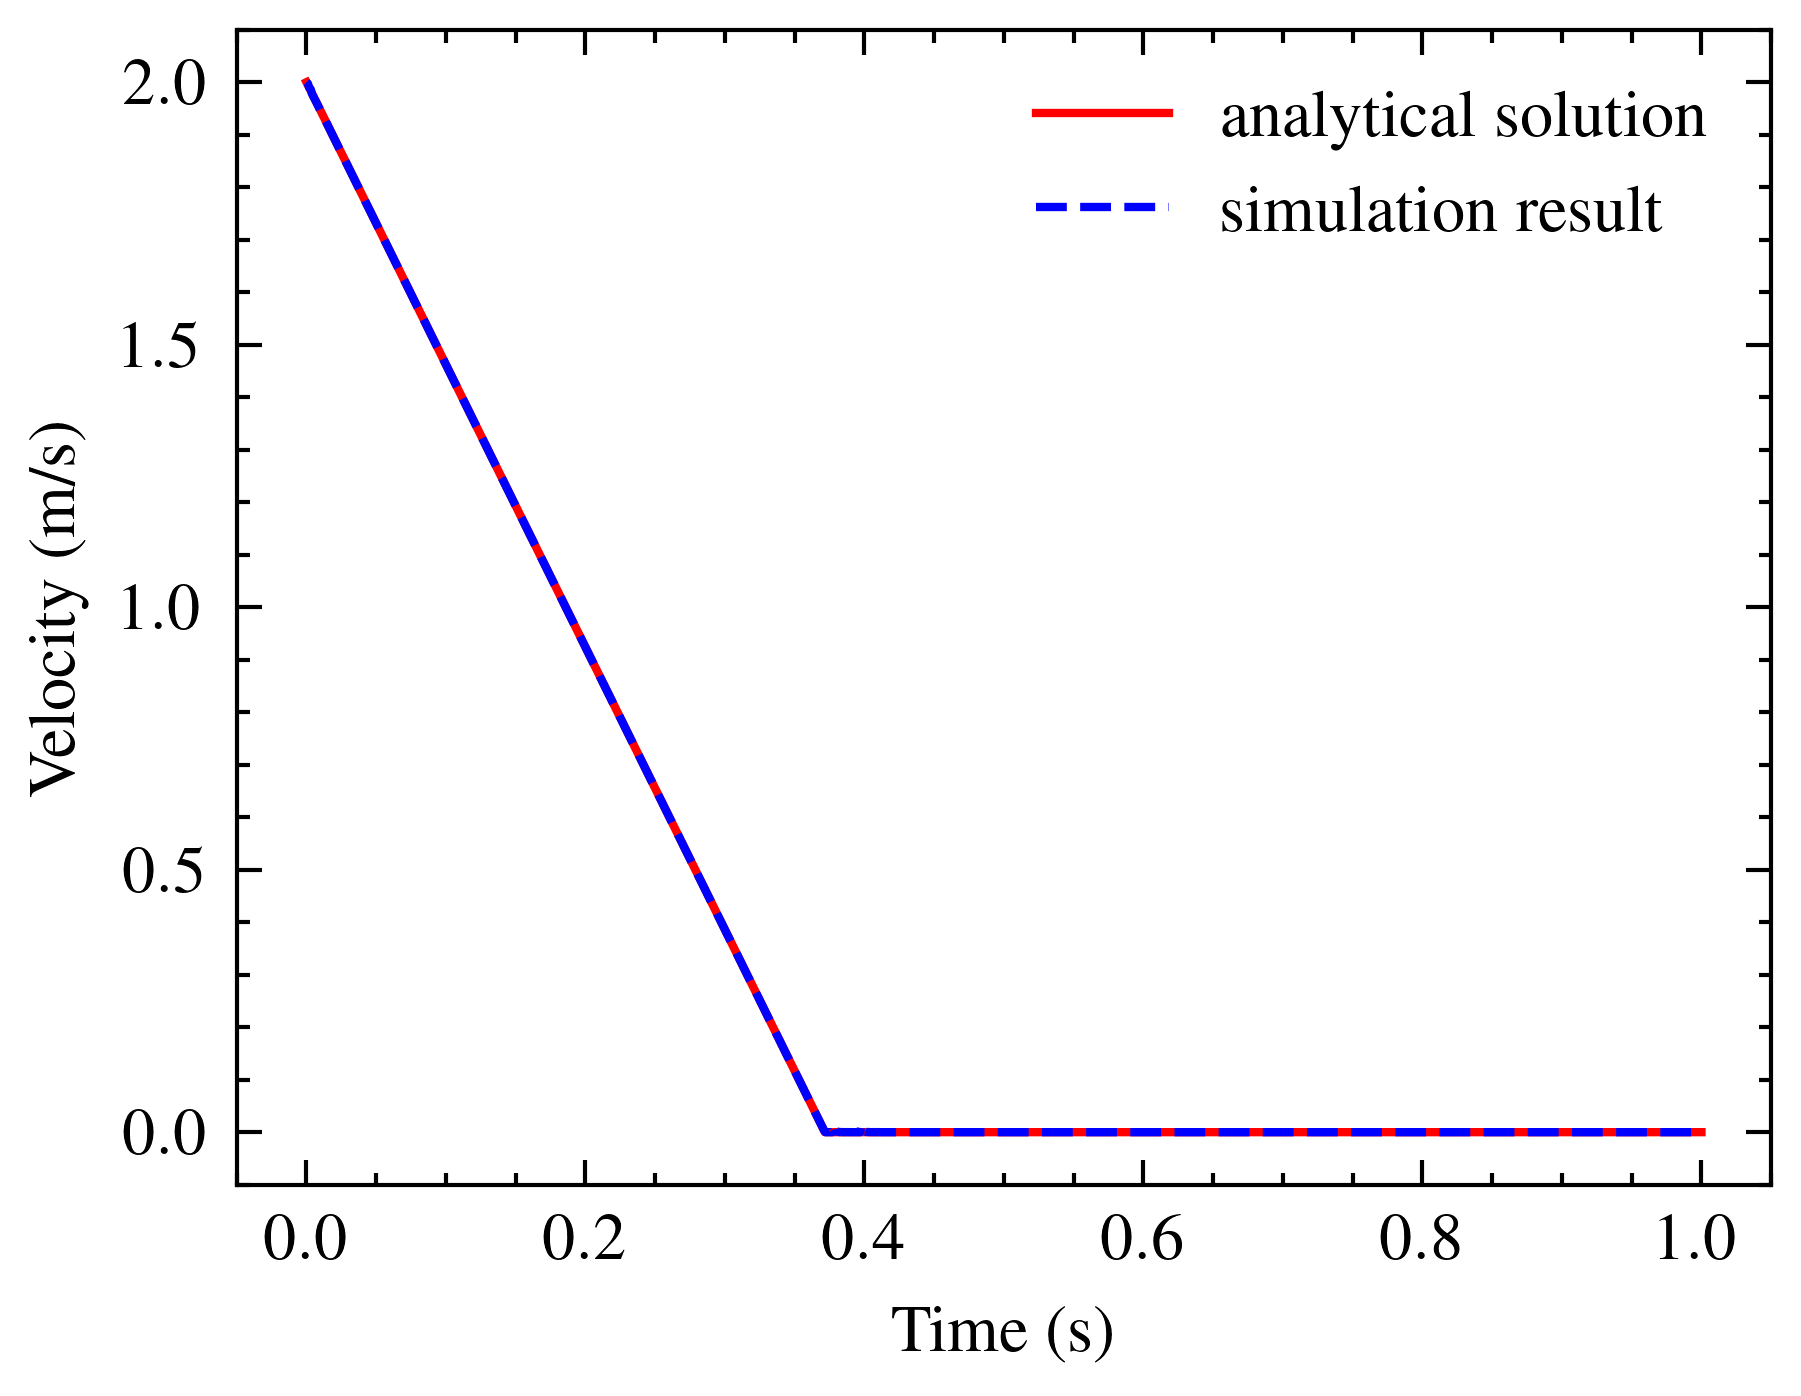

In [2]:
import numpy as np
plot_time = 1
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
dts = result["dts"]
x = []
y = []
yv = []

lowerBound = sire.binarySearch(timeIndices, 0)
upperBound = sire.binarySearch(timeIndices, 0 + plot_time)
print(timeIndices[lowerBound], timeIndices[lowerBound + 1])
for i in range(lowerBound, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  pm = sire.pq2tfmatrix(partpq[i][1])
  yOffset = pm[1, 3]
  zOffset = pm[2, 3] - cube_pe[2]
  y.append(math.sqrt(yOffset ** 2 + zOffset ** 2))  # z position from transformation matrix
  yv.append(math.sqrt(partvs[i][1][2] ** 2 + partvs[i][1][1]**2))  # z velocity

t = 2 / (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15)))
xt = 2 * t - 0.5 * (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * t ** 2
x2 = np.linspace(0, plot_time, 10000)
y2 = np.piecewise(x2, 
                 [x2 <= t, x2 > t], 
                 [lambda x: 2 * x - 0.5 * (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * x ** 2, lambda x: xt])
with plt.style.context(['science','ieee']):
  plt.plot(x2, y2, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, y, color='blue', linestyle="--", label="simulation result")
  plt.legend()
  plt.xlabel("Time (s)")
  plt.ylabel("Displacement (m)")
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data2.pdf", format="pdf")
  plt.show()

  x1 = np.linspace(0, plot_time, 10000)
  y1 = np.piecewise(x1, 
                   [x1 < t, x1 >= t], 
                   [lambda x: 2 - (9.81 * math.sin(math.radians(15)) + 0.3 * 9.81 * math.cos(math.radians(15))) * x, lambda x: 0])
  plt.plot(x1, y1, color='red', linestyle="-", label="analytical solution")
  plt.plot(x, yv, color='blue', linestyle="--", label="simulation result")
  plt.xlabel("Time (s)")
  plt.ylabel("Velocity (m/s)")
  plt.legend()
  plt.show()


  Sire Accuracy Metrics — Box Sliding on 15° Incline

                                  — Full Trajectory (0 — 1.0s) —
                                    Displacement        Velocity
  --------------------------------------------------------------
  RMSE:                                 0.000877        0.000740
  MAE:                                  0.000822        0.000057
  Max absolute error:                   0.001015        0.015769
  R² score:                             0.999905        0.999998

                                 — Stable Phase (t >= 0.3716s) —
  Analytical final displacement:        0.371627 m
  Sire mean displacement:               0.370613 m
  Sire displacement std:                0.000003 m
  Sire velocity std:                    0.000914 m/s
  Displacement abs diff:                0.001014 m
  Displacement rel diff:                  0.2730 %
  Displacement RMSE:                    0.001014 m
  Velocity RMSE:                        0.000918 m/s
[0.00e+00 1.

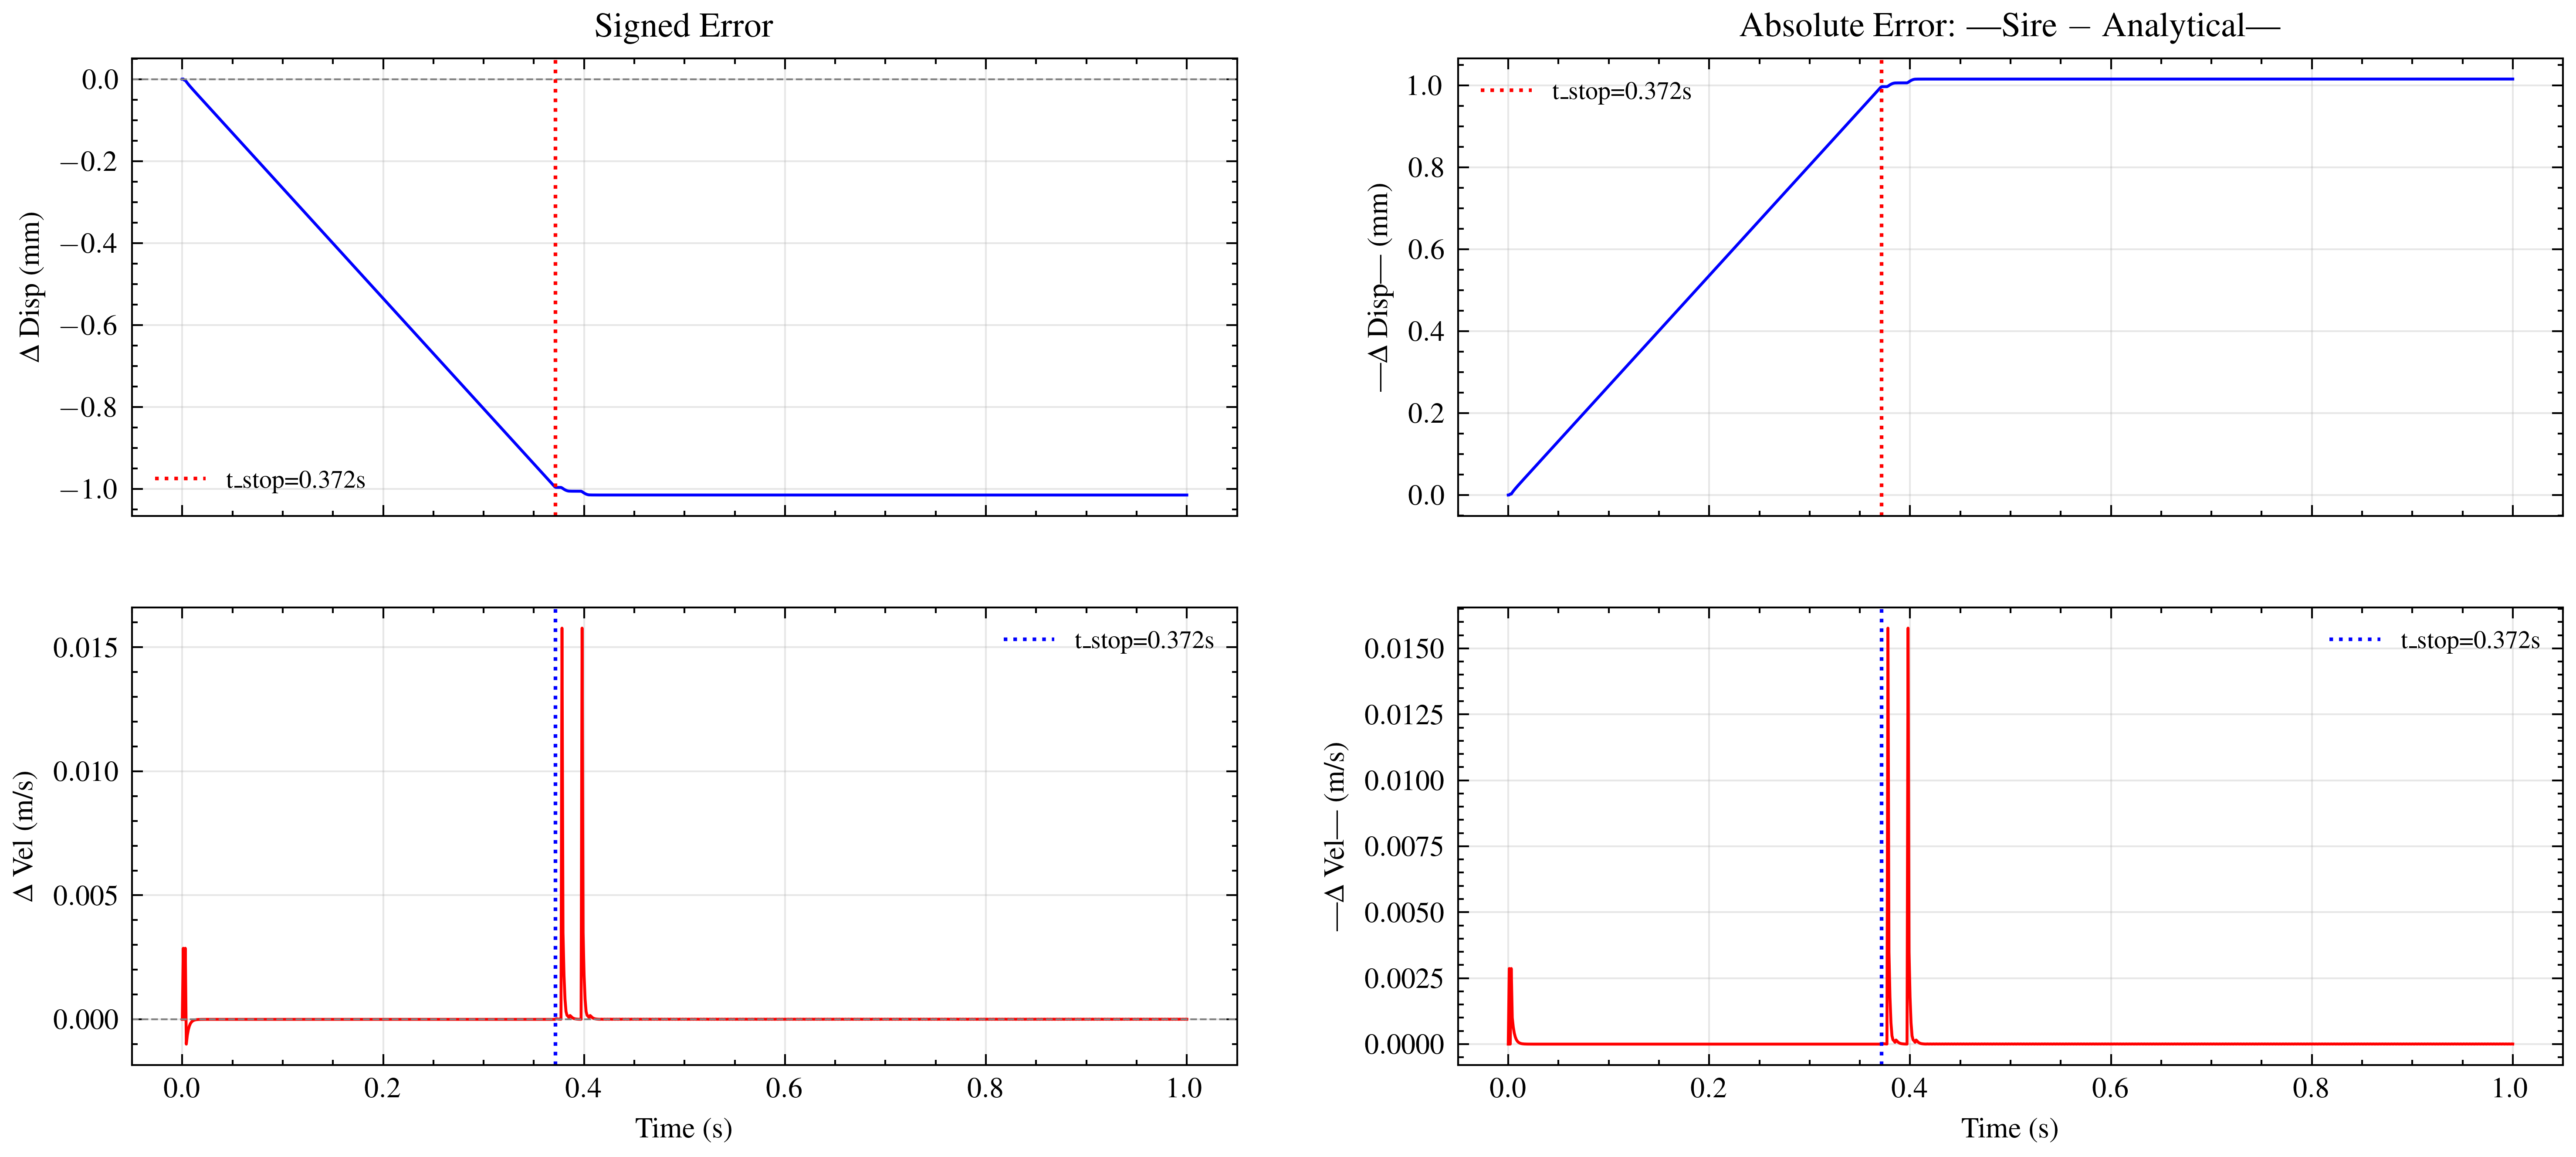

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ======================== Parameters & Analytical ========================
angle_deg = 15
angle_rad = math.radians(angle_deg)
g = 9.81
mu = 0.3
v0 = 2.0
a_decel = g * math.sin(angle_rad) + mu * g * math.cos(angle_rad)
t_stop = v0 / a_decel
x_stop = v0 * t_stop - 0.5 * a_decel * t_stop**2

# ======================== Analytical curves (fine grid) ========================
t_ana = np.linspace(0, 0.6, 10000)
disp_ana = np.piecewise(t_ana,
                        [t_ana <= t_stop, t_ana > t_stop],
                        [lambda t: v0*t - 0.5*a_decel*t**2,
                         lambda t: x_stop])
vel_ana = np.piecewise(t_ana,
                       [t_ana < t_stop, t_ana >= t_stop],
                       [lambda t: v0 - a_decel*t,
                        lambda t: 0])

# Interpolate analytical onto sire time points
x_arr = np.array(x)
y_arr = np.array(y)
yv_arr = np.array(yv)

disp_ana_at_sire = np.interp(x_arr, t_ana, disp_ana)
vel_ana_at_sire = np.interp(x_arr, t_ana, vel_ana)

# ======================== Full-Trajectory Errors ========================
disp_error = y_arr - disp_ana_at_sire
vel_error = yv_arr - vel_ana_at_sire

disp_rmse_full = np.sqrt(np.mean(disp_error**2))
vel_rmse_full = np.sqrt(np.mean(vel_error**2))
disp_mae_full = np.mean(np.abs(disp_error))
vel_mae_full = np.mean(np.abs(vel_error))
disp_max_err = np.max(np.abs(disp_error))
vel_max_err = np.max(np.abs(vel_error))

ss_res_d = np.sum(disp_error**2)
ss_tot_d = np.sum((y_arr - np.mean(y_arr))**2)
r2_disp = 1 - ss_res_d / ss_tot_d if ss_tot_d > 1e-15 else 1.0

ss_res_v = np.sum(vel_error**2)
ss_tot_v = np.sum((yv_arr - np.mean(yv_arr))**2)
r2_vel = 1 - ss_res_v / ss_tot_v if ss_tot_v > 1e-15 else 1.0

# ======================== Stable-Phase Errors ========================
stable_mask = x_arr >= t_stop
sire_stable_disp = y_arr[stable_mask]
sire_stable_vel = yv_arr[stable_mask]
stable_disp_mean = np.mean(sire_stable_disp)
stable_disp_std = np.std(sire_stable_disp)
stable_vel_std = np.std(sire_stable_vel)
stable_disp_abs_diff = abs(stable_disp_mean - x_stop)
stable_disp_rmse = np.sqrt(np.mean((sire_stable_disp - x_stop)**2))
stable_vel_rmse = np.sqrt(np.mean(sire_stable_vel**2))

# ======================== Print Results ========================
print(f"\n{'='*62}")
print(f"  Sire Accuracy Metrics — Box Sliding on {angle_deg}° Incline")
print(f"{'='*62}")

traj_label = f"— Full Trajectory (0 — {plot_time:.1f}s) —"
print(f"\n  {traj_label:>62}")
print(f"  {'':>30} {'Displacement':>15} {'Velocity':>15}")
print(f"  {'-'*62}")
print(f"  {'RMSE:':<30} {disp_rmse_full:>15.6f} {vel_rmse_full:>15.6f}")
print(f"  {'MAE:':<30} {disp_mae_full:>15.6f} {vel_mae_full:>15.6f}")
print(f"  {'Max absolute error:':<30} {disp_max_err:>15.6f} {vel_max_err:>15.6f}")
print(f"  {'R² score:':<30} {r2_disp:>15.6f} {r2_vel:>15.6f}")

stable_label = f"— Stable Phase (t >= {t_stop:.4f}s) —"
print(f"\n  {stable_label:>62}")
print(f"  {'Analytical final displacement:':<30} {x_stop:>15.6f} m")
print(f"  {'Sire mean displacement:':<30} {stable_disp_mean:>15.6f} m")
print(f"  {'Sire displacement std:':<30} {stable_disp_std:>15.6f} m")
print(f"  {'Sire velocity std:':<30} {stable_vel_std:>15.6f} m/s")
print(f"  {'Displacement abs diff:':<30} {stable_disp_abs_diff:>15.6f} m")
print(f"  {'Displacement rel diff:':<30} {stable_disp_abs_diff/x_stop*100:>15.4f} %")
print(f"  {'Displacement RMSE:':<30} {stable_disp_rmse:>15.6f} m")
print(f"  {'Velocity RMSE:':<30} {stable_vel_rmse:>15.6f} m/s")
print(f"{'='*62}")

# ======================== Plots ========================
with plt.style.context(['science', 'ieee']):
    # --- Error-over-time (2x2: signed + absolute) ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)

    axes[0, 0].plot(x_arr, disp_error * 1000, 'b-', linewidth=0.8)
    axes[0, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    axes[0, 0].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[0, 0].set_ylabel("$\\Delta$ Disp (mm)")
    axes[0, 0].set_title("Signed Error")
    axes[0, 0].legend(fontsize=7)
    axes[0, 0].grid(True, alpha=0.3)
    np.set_printoptions(threshold=np.inf)
    print(x_arr)
    print(disp_error)
    print(vel_error)

    axes[0, 1].plot(x_arr, np.abs(disp_error) * 1000, 'b-', linewidth=0.8)
    axes[0, 1].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[0, 1].set_ylabel("|$\\Delta$ Disp| (mm)")
    axes[0, 1].set_title("Absolute Error: |Sire $-$ Analytical|")
    axes[0, 1].legend(fontsize=7)
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(x_arr, vel_error, 'r-', linewidth=0.8)
    axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    axes[1, 0].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[1, 0].set_xlabel("Time (s)")
    axes[1, 0].set_ylabel("$\\Delta$ Vel (m/s)")
    axes[1, 0].legend(fontsize=7)
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(x_arr, np.abs(vel_error), 'r-', linewidth=0.8)
    axes[1, 1].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
    axes[1, 1].set_xlabel("Time (s)")
    axes[1, 1].set_ylabel("|$\\Delta$ Vel| (m/s)")
    axes[1, 1].legend(fontsize=7)
    axes[1, 1].grid(True, alpha=0.3)

    plt.show()

  Box Sliding on 15° Incline — MuJoCo Simulation
  Gravity:          9.81 m/s²
  Friction (μ):     0.3
  Initial velocity: 2.0 m/s (uphill)
  Deceleration:     5.3817 m/s²
  Analytical stop:  t = 0.3716 s,  x = 0.3716 m
  Ramp center z:    0.5000 m
  Cube center z:    1.5353 m
  Initial velocity:  0 (box at rest, press ENTER in viewer to start)
Data collected: 1000 steps, dt = 0.001000s


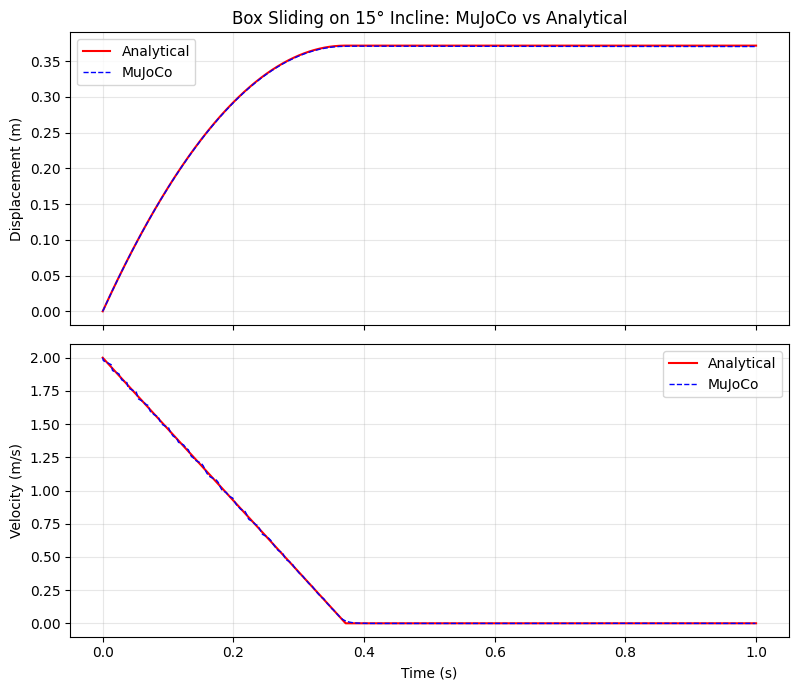


  Accuracy Metrics

                                  — Full Trajectory (0 — 1.0s) —
                                    Displacement        Velocity
  --------------------------------------------------------------
  RMSE:                                 0.000905        0.004661
  MAE:                                  0.000846        0.002787
  Max absolute error:                   0.001293        0.017755
  R² score:                             0.999899        0.999939

                                 — Stable Phase (t >= 0.3716s) —
  Analytical final displacement:        0.371627 m
  MuJoCo mean displacement:             0.370588 m
  MuJoCo displacement std:              0.000144 m
  MuJoCo velocity std:                  0.001598 m/s
  Displacement abs diff:                0.001039 m
  Displacement rel diff:                  0.2796 %
  Displacement RMSE:                    0.001049 m
  Velocity RMSE:                        0.001699 m/s


[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035
 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047
 0.048 0.049 0.05  0.051 0.052 0.053 0.054 0.055 0.056 0.057 0.058 0.059
 0.06  0.061 0.062 0.063 0.064 0.065 0.066 0.067 0.068 0.069 0.07  0.071
 0.072 0.073 0.074 0.075 0.076 0.077 0.078 0.079 0.08  0.081 0.082 0.083
 0.084 0.085 0.086 0.087 0.088 0.089 0.09  0.091 0.092 0.093 0.094 0.095
 0.096 0.097 0.098 0.099 0.1   0.101 0.102 0.103 0.104 0.105 0.106 0.107
 0.108 0.109 0.11  0.111 0.112 0.113 0.114 0.115 0.116 0.117 0.118 0.119
 0.12  0.121 0.122 0.123 0.124 0.125 0.126 0.127 0.128 0.129 0.13  0.131
 0.132 0.133 0.134 0.135 0.136 0.137 0.138 0.139 0.14  0.141 0.142 0.143
 0.144 0.145 0.146 0.147 0.148 0.149 0.15  0.151 0.152 0.153 0.154 0.155
 0.156 0.157 0.158 0.159 0.16  0.161 0.162 0.163 0.

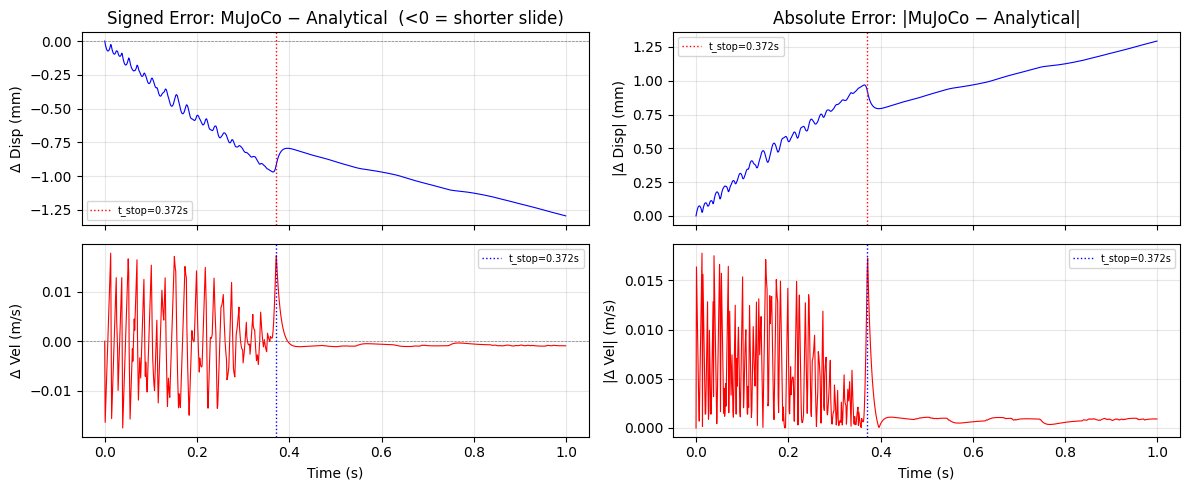

<Figure size 640x480 with 0 Axes>

In [ ]:
"""
MuJoCo Simulation: Box Sliding on 15° Inclined Plane
=====================================================
A 1×1×1m box (with 4 corner spheres) slides on a 15° incline.
Initial velocity: 2 m/s along the incline.
Friction coefficient: μ = 0.3.

Run: python mujocoBoxSliding.py
Requires: pip install mujoco matplotlib numpy
"""

import mujoco
import numpy as np
import math
import matplotlib.pyplot as plt
import mujoco.viewer

# ======================== Parameters ========================
angle_deg = 15
angle_rad = math.radians(angle_deg)
g = 9.81
mu = 0.3        # friction coefficient
v0 = 2.0        # initial velocity (m/s) along the incline
dt = 0.001     # simulation timestep (s)

# ======================== Analytical Solution ========================
# Deceleration: a = g*sin(θ) + μ*g*cos(θ)  (gravity + friction both oppose uphill motion)
a_decel = g * math.sin(angle_rad) + mu * g * math.cos(angle_rad)
t_stop = v0 / a_decel
x_stop = v0 * t_stop - 0.5 * a_decel * t_stop**2

print(f"{'='*50}")
print(f"  Box Sliding on {angle_deg}° Incline — MuJoCo Simulation")
print(f"{'='*50}")
print(f"  Gravity:          {g} m/s²")
print(f"  Friction (μ):     {mu}")
print(f"  Initial velocity: {v0} m/s (uphill)")
print(f"  Deceleration:     {a_decel:.4f} m/s²")
print(f"  Analytical stop:  t = {t_stop:.4f} s,  x = {x_stop:.4f} m")
print(f"{'='*50}")

# ======================== Geometry Calculation ========================
# Ramp: box half-extent (3, 3, 0.5), center at z=0.5, rotated -15° about X.
#   Top surface at y=0: z_ramp_top = 0.5 + 0.5*cos(15°) ≈ 0.983
# Cube: half-extent 0.5, also rotated -15° about X.
#   Bottom offset from center = 0.5*cos(15°) ≈ 0.483
#   Cube center z = ramp_top + bottom_offset + tiny_gap ≈ 1.4665
ramp_z = 0.5
cube_z = ramp_z + 1 / math.cos(angle_rad)  # +2mm gap to avoid initial bounce
print(f"  Ramp center z:    {ramp_z:.4f} m")
print(f"  Cube center z:    {cube_z:.4f} m")
print(f"{'='*50}")

# ======================== Build MuJoCo Model ========================
# NOTE: MuJoCo XML euler angles are in DEGREES, not radians!
#  cone="elliptic" noslip_iterations="5"
# <geom solref="0.005 0.5"/>
xml = f"""
<mujoco model="box_sliding">
  <default>
    <geom solref="0.005 0.5"/>
  </default>
  <option timestep="{dt}" gravity="0 0 -9.81" cone="elliptic" noslip_iterations="5">
    <flag contact="enable"/>
  </option>
  <worldbody>
    <light pos="0 5 10"/>
    <camera pos="3 -3 3" xyaxes="0.707 0.707 0 -0.408 0.408 0.816"/>

    <!-- Ground reference plane -->
    <geom type="plane" size="10 10 0.1" rgba="0.3 0.3 0.3 1"/>

    <!-- Inclined ramp: box half-extent [3, 3, 0.5], rotated -15° about X (matching sire) -->
    <body pos="0 0 {ramp_z}" euler="-{angle_deg} 0 0">
      <geom type="box" size="3 3 0.5" rgba="0.5 0.5 0.5 1" friction="{mu} 0.01 0.001"/>
    </body>

    <!-- Sliding box: 1×1×1 cube, rotated -15° about X -->
    <body pos="0 0 {cube_z}" euler="-{angle_deg} 0 0">
      <freejoint/>
      <geom type="box" size="0.5 0.5 0.5" rgba="0.2 0.4 0.8 1" mass="1"
            friction="{mu} 0.01 0.001"/>
    </body>
  </worldbody>
</mujoco>
"""
#       <joint type="free" stiffness="0" damping="10" frictionloss="0" armature="0"/>
# Load model
mj_model = mujoco.MjModel.from_xml_string(xml)
mj_data = mujoco.MjData(mj_model)

# ======================== Initial State ========================
# Box starts at REST on the incline (velocity set to 0 initially).
# The viewer will let you inspect the scene, then apply velocity on ENTER.
print(f"  Initial velocity:  0 (box at rest, press ENTER in viewer to start)")
print(f"{'='*50}")

# # ======================== Visual Check (Interactive Viewer) ========================
# Box starts at REST on the ramp. Press ENTER to apply uphill velocity.
# print("\n>>> Launching MuJoCo viewer...")
# print("    Box is at REST on the incline — inspect the scene first.")
# print("    [Right-drag] rotate  |  [Scroll] zoom  |  [Middle-drag] pan")
# print("    Press ENTER in this console to START sliding.\n")

# with mujoco.viewer.launch_passive(mj_model, mj_data, show_left_ui=True, show_right_ui=True) as viewer:
#     import time

#     # Phase 1: render static scene WITHOUT stepping (no gravity creep)
#     viewer.sync()
#     input(">>> Press ENTER to apply initial velocity (2 m/s uphill) and start...")

#     # Apply initial velocity (uphill along incline)
#     mj_data.qvel[0] = 0
#     mj_data.qvel[1] = -v0 * math.cos(angle_rad)   # -y = uphill
#     mj_data.qvel[2] = v0 * math.sin(angle_rad)     # +z = uphill
#     print("    Box sliding! Close viewer window when done.\n")

#     sim_time_prev = mj_data.time
#     while viewer.is_running():
#         mujoco.mj_step(mj_model, mj_data)
#         viewer.sync()
#         # Slow down playback: ~200 fps real-time display (5ms per frame)
#         time.sleep(0.005)

# print("Viewer closed. Collecting data...\n")

# ======================== Full Simulation (Data Collection) ========================
# Reset
mj_data = mujoco.MjData(mj_model)
mj_data.qvel[0] = 0
mj_data.qvel[1] = -v0 * math.cos(angle_rad)
mj_data.qvel[2] = v0 * math.sin(angle_rad)

sim_duration = 1
dt = mj_model.opt.timestep
n_steps = int(sim_duration / dt)

# Incline direction (downhill unit vector in world frame)
incline_dir = np.array([0, -math.cos(angle_rad), math.sin(angle_rad)])

t_hist = np.zeros(n_steps)
disp_hist = np.zeros(n_steps)   # displacement along incline
vel_hist = np.zeros(n_steps)    # velocity along incline
init_pos = mj_data.qpos[0:3].copy()

for step in range(n_steps):
    t_hist[step] = mj_data.time
    delta = mj_data.qpos[0:3] - init_pos
    disp_hist[step] = np.dot(delta, incline_dir)
    vel_hist[step] = np.dot(mj_data.qvel[0:3], incline_dir)
    mujoco.mj_step(mj_model, mj_data)

print(f"Data collected: {n_steps} steps, dt = {dt:.6f}s")

# ======================== Analytical Curves ========================
t_ana = np.linspace(0, sim_duration, 10000)
disp_ana = np.piecewise(t_ana,
                        [t_ana <= t_stop, t_ana > t_stop],
                        [lambda t: v0*t - 0.5*a_decel*t**2,
                         lambda t: x_stop])
vel_ana = np.piecewise(t_ana,
                       [t_ana < t_stop, t_ana >= t_stop],
                       [lambda t: v0 - a_decel*t,
                        lambda t: 0])

# ======================== Plot: MuJoCo vs Analytical ========================
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Displacement
axes[0].plot(t_ana, disp_ana, 'r-', linewidth=1.5, label='Analytical')
axes[0].plot(t_hist, disp_hist, 'b--', linewidth=1.0, label='MuJoCo')
axes[0].set_ylabel("Displacement (m)")
axes[0].legend()
axes[0].set_title(f"Box Sliding on {angle_deg}° Incline: MuJoCo vs Analytical")
axes[0].grid(True, alpha=0.3)

# Velocity
axes[1].plot(t_ana, vel_ana, 'r-', linewidth=1.5, label='Analytical')
axes[1].plot(t_hist, vel_hist, 'b--', linewidth=1.0, label='MuJoCo')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Velocity (m/s)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ======================== Quantitative Comparison ========================

# Interpolate analytical solution onto MuJoCo time points for pointwise comparison
disp_ana_at_mj = np.interp(t_hist, t_ana, disp_ana)
vel_ana_at_mj = np.interp(t_hist, t_ana, vel_ana)

# --- Full trajectory errors ---
disp_error = disp_hist - disp_ana_at_mj
vel_error = vel_hist - vel_ana_at_mj

disp_rmse_full = np.sqrt(np.mean(disp_error**2))
vel_rmse_full = np.sqrt(np.mean(vel_error**2))
disp_mae_full = np.mean(np.abs(disp_error))
vel_mae_full = np.mean(np.abs(vel_error))
disp_max_err = np.max(np.abs(disp_error))
vel_max_err = np.max(np.abs(vel_error))

# R² scores
ss_res_disp = np.sum(disp_error**2)
ss_tot_disp = np.sum((disp_hist - np.mean(disp_hist))**2)
r2_disp = 1 - ss_res_disp / ss_tot_disp if ss_tot_disp > 1e-15 else 1.0

ss_res_vel = np.sum(vel_error**2)
ss_tot_vel = np.sum((vel_hist - np.mean(vel_hist))**2)
r2_vel = 1 - ss_res_vel / ss_tot_vel if ss_tot_vel > 1e-15 else 1.0

# --- Stable phase errors ---
stable_mask = t_hist >= t_stop
mj_stable_disp = disp_hist[stable_mask]
mj_stable_vel = vel_hist[stable_mask]
mj_disp_mean = np.mean(mj_stable_disp)
mj_disp_std = np.std(mj_stable_disp)
mj_vel_std = np.std(mj_stable_vel)
mj_disp_abs_diff = abs(mj_disp_mean - x_stop)
mj_disp_rmse = np.sqrt(np.mean((mj_stable_disp - x_stop)**2))
mj_vel_rmse = np.sqrt(np.mean(mj_stable_vel**2))

# --- Print results ---
print(f"\n{'='*62}")
print(f"  Accuracy Metrics")
print(f"{'='*62}")

traj_label = f"— Full Trajectory (0 — {sim_duration:.1f}s) —"
print(f"\n  {traj_label:>62}")
print(f"  {'':>30} {'Displacement':>15} {'Velocity':>15}")
print(f"  {'-'*62}")
print(f"  {'RMSE:':<30} {disp_rmse_full:>15.6f} {vel_rmse_full:>15.6f}")
print(f"  {'MAE:':<30} {disp_mae_full:>15.6f} {vel_mae_full:>15.6f}")
print(f"  {'Max absolute error:':<30} {disp_max_err:>15.6f} {vel_max_err:>15.6f}")
print(f"  {'R² score:':<30} {r2_disp:>15.6f} {r2_vel:>15.6f}")

stable_label = f"— Stable Phase (t >= {t_stop:.4f}s) —"
print(f"\n  {stable_label:>62}")
print(f"  {'Analytical final displacement:':<30} {x_stop:>15.6f} m")
print(f"  {'MuJoCo mean displacement:':<30} {mj_disp_mean:>15.6f} m")
print(f"  {'MuJoCo displacement std:':<30} {mj_disp_std:>15.6f} m")
print(f"  {'MuJoCo velocity std:':<30} {mj_vel_std:>15.6f} m/s")
print(f"  {'Displacement abs diff:':<30} {mj_disp_abs_diff:>15.6f} m")
print(f"  {'Displacement rel diff:':<30} {mj_disp_abs_diff/x_stop*100:>15.4f} %")
print(f"  {'Displacement RMSE:':<30} {mj_disp_rmse:>15.6f} m")
print(f"  {'Velocity RMSE:':<30} {mj_vel_rmse:>15.6f} m/s")
print(f"{'='*62}")

# --- Error-over-time plots (left: signed, right: absolute) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)

# Signed displacement error
axes[0, 0].plot(t_hist, disp_error * 1000, 'b-', linewidth=0.8)
axes[0, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
axes[0, 0].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
axes[0, 0].set_ylabel("Δ Disp (mm)")
axes[0, 0].set_title("Signed Error: MuJoCo − Analytical  (<0 = shorter slide)")
axes[0, 0].legend(fontsize=7)
axes[0, 0].grid(True, alpha=0.3)
print(t_hist)
print(disp_error)
print(vel_error)

# Absolute displacement error
axes[0, 1].plot(t_hist, np.abs(disp_error) * 1000, 'b-', linewidth=0.8)
axes[0, 1].axvline(x=t_stop, color='r', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
axes[0, 1].set_ylabel("|Δ Disp| (mm)")
axes[0, 1].set_title("Absolute Error: |MuJoCo − Analytical|")
axes[0, 1].legend(fontsize=7)
axes[0, 1].grid(True, alpha=0.3)

# Signed velocity error
axes[1, 0].plot(t_hist, vel_error, 'r-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
axes[1, 0].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Δ Vel (m/s)")
axes[1, 0].legend(fontsize=7)
axes[1, 0].grid(True, alpha=0.3)

# Absolute velocity error
axes[1, 1].plot(t_hist, np.abs(vel_error), 'r-', linewidth=0.8)
axes[1, 1].axvline(x=t_stop, color='b', linestyle=':', linewidth=1.0, label=f't_stop={t_stop:.3f}s')
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("|Δ Vel| (m/s)")
axes[1, 1].legend(fontsize=7)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()